# Итоговый отчёт v0.4 geo-sync

**Тема:** Моделирование и визуализация угроз в мобильных P2P-сетях на базе геоданных.

Ноутбук автоматически работает с двумя режимами координат:

- `plane` — условная координатная плоскость, совместимая с ранними результатами;
- `geo` — реальные координаты внутри bbox и haversine-метрика.

При отсутствии таблиц ноутбук может перегенерировать результаты через `src/run_experiment.py` и `src/run_multi_seed.py`.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path("..").resolve() if Path("../src").exists() else Path(".").resolve()
os.chdir(PROJECT_ROOT)

RUN_COORDS = ["plane", "geo"]       # можно оставить только ["plane"] или ["geo"]
GRAPH_TYPES = ["radius", "knn"]
SCENARIOS = ["baseline", "rogue", "flooding", "isolation", "spoofing"]
AUTO_RUN_MISSING = True
MULTI_SEED_RUNS = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)

Project root: /Users/vladimir/Desktop/vkr/vkr_final_v0_4_1_repo_ready
Python: /Users/vladimir/Desktop/vkr/venv/bin/python


In [2]:
def coord_root(coord: str) -> Path:
    return Path("outputs") if coord == "plane" else Path("outputs") / "geo"

def summary_path(coord: str, graph: str) -> Path:
    return coord_root(coord) / "tables" / graph / "summary_metrics.csv"

def stability_path(coord: str) -> Path:
    return coord_root(coord) / "tables" / "stability_metrics.csv"

def run_cmd(cmd: list[str], desc: str) -> None:
    print(f"\n==> {desc}")
    print(" ".join(cmd))
    result = subprocess.run(cmd, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed with code {result.returncode}: {' '.join(cmd)}")

def ensure_results(coord: str) -> None:
    missing_summaries = [summary_path(coord, graph) for graph in GRAPH_TYPES if not summary_path(coord, graph).exists()]
    missing_stability = not stability_path(coord).exists()

    if not AUTO_RUN_MISSING:
        for path in missing_summaries:
            print("Missing:", path)
        if missing_stability:
            print("Missing:", stability_path(coord))
        return

    if missing_summaries:
        run_cmd([sys.executable, "src/run_experiment.py", "--all-graphs", "--coord", coord], f"Generate {coord} summaries")
    if missing_stability:
        run_cmd([sys.executable, "src/run_multi_seed.py", "--runs", str(MULTI_SEED_RUNS), "--coord", coord], f"Generate {coord} stability")

for coord in RUN_COORDS:
    ensure_results(coord)

print("\nГотово к построению отчёта.")


==> Generate plane summaries
/Users/vladimir/Desktop/vkr/venv/bin/python src/run_experiment.py --all-graphs --coord plane

=== PLANE / RADIUS / BASELINE ===
                             Baseline  After Threat  Change
nodes                       50.000000     50.000000     0.0
edges                       82.000000     82.000000     0.0
density                      0.066939      0.066939     0.0
avg_degree                   3.280000      3.280000     0.0
num_components               7.000000      7.000000     0.0
largest_component_size      34.000000     34.000000     0.0
isolated_nodes               2.000000      2.000000     0.0
avg_clustering               0.516905      0.516905     0.0
max_degree_centrality        0.163265      0.163265     0.0
max_betweenness_centrality   0.256803      0.256803     0.0
degree_centrality_std        0.038080      0.038080     0.0
total_load                   0.000000      0.000000     0.0
max_load                     0.000000      0.000000     0.0
av

## 1. Сводные таблицы по режимам координат и типам графов

In [3]:
summaries: dict[tuple[str, str], pd.DataFrame] = {}

for coord in RUN_COORDS:
    for graph in GRAPH_TYPES:
        path = summary_path(coord, graph)
        display(Markdown(f"### {coord.upper()} / {graph.upper()} — summary_metrics.csv"))
        if path.exists():
            df = pd.read_csv(path, index_col=0)
            summaries[(coord, graph)] = df
            display(df)
        else:
            display(Markdown(f"**Файл не найден:** `{path}`"))

### PLANE / RADIUS — summary_metrics.csv

,Baseline,Rogue,Flooding,Isolation,Spoofing
nodes,50.0000,50.0000,50.0000,50.0000,51.0000
edges,82.0000,96.0000,82.0000,77.0000,87.0000
density,0.0669,0.0784,0.0669,0.0629,0.0682
avg_degree,3.2800,3.8400,3.2800,3.0800,3.4118
num_components,7.0000,3.0000,7.0000,10.0000,6.0000
largest_component_size,34.0000,41.0000,34.0000,18.0000,38.0000
isolated_nodes,2.0000,0.0000,2.0000,4.0000,2.0000
avg_clustering,0.5169,0.6065,0.5169,0.4609,0.4832
max_degree_centrality,0.1633,0.2857,0.1633,0.1633,0.1600
max_betweenness_centrality,0.2568,0.4413,0.2568,0.0408,0.2629


### PLANE / KNN — summary_metrics.csv

,Baseline,Rogue,Flooding,Isolation,Spoofing
nodes,50.0000,50.0000,50.0000,50.0000,51.0000
edges,150.0000,159.0000,150.0000,132.0000,155.0000
density,0.1224,0.1298,0.1224,0.1078,0.1216
avg_degree,6.0000,6.3600,6.0000,5.2800,6.0784
num_components,1.0000,1.0000,1.0000,4.0000,1.0000
largest_component_size,50.0000,50.0000,50.0000,47.0000,51.0000
isolated_nodes,0.0000,0.0000,0.0000,3.0000,0.0000
avg_clustering,0.6373,0.6523,0.6373,0.5978,0.6094
max_degree_centrality,0.1837,0.2857,0.1837,0.1837,0.1800
max_betweenness_centrality,0.2641,0.2581,0.2641,0.2216,0.2320


### GEO / RADIUS — summary_metrics.csv

,Baseline,Rogue,Flooding,Isolation,Spoofing
nodes,50.0000,50.0000,50.0000,50.0000,51.0000
edges,23.0000,28.0000,23.0000,21.0000,28.0000
density,0.0188,0.0229,0.0188,0.0171,0.0220
avg_degree,0.9200,1.1200,0.9200,0.8400,1.0980
num_components,29.0000,24.0000,29.0000,31.0000,25.0000
largest_component_size,7.0000,8.0000,7.0000,7.0000,15.0000
isolated_nodes,19.0000,14.0000,19.0000,22.0000,18.0000
avg_clustering,0.0933,0.0933,0.0933,0.0933,0.0784
max_degree_centrality,0.0612,0.1020,0.0612,0.0612,0.1000
max_betweenness_centrality,0.0094,0.0153,0.0094,0.0094,0.0604


### GEO / KNN — summary_metrics.csv

,Baseline,Rogue,Flooding,Isolation,Spoofing
nodes,50.0000,50.0000,50.0000,50.0000,51.0000
edges,151.0000,151.0000,151.0000,132.0000,156.0000
density,0.1233,0.1233,0.1233,0.1078,0.1224
avg_degree,6.0400,6.0400,6.0400,5.2800,6.1176
num_components,1.0000,1.0000,1.0000,4.0000,1.0000
largest_component_size,50.0000,50.0000,50.0000,47.0000,51.0000
isolated_nodes,0.0000,0.0000,0.0000,3.0000,0.0000
avg_clustering,0.6414,0.6414,0.6414,0.5979,0.6130
max_degree_centrality,0.1837,0.1837,0.1837,0.1837,0.1800
max_betweenness_centrality,0.2634,0.2634,0.2634,0.2241,0.2176


## 2. Сравнение baseline для radius и k-NN

In [4]:
for coord in RUN_COORDS:
    if (coord, "radius") not in summaries or (coord, "knn") not in summaries:
        continue

    df_radius = summaries[(coord, "radius")]
    df_knn = summaries[(coord, "knn")]
    comparison = pd.DataFrame({
        "Метрика": ["Рёбер", "Компонент связности", "Размер LCC", "Изолированных узлов", "Плотность", "Средняя степень"],
        "Radius Graph": [
            df_radius.loc["edges", "Baseline"],
            df_radius.loc["num_components", "Baseline"],
            df_radius.loc["largest_component_size", "Baseline"],
            df_radius.loc["isolated_nodes", "Baseline"],
            df_radius.loc["density", "Baseline"],
            df_radius.loc["avg_degree", "Baseline"],
        ],
        "k-NN Graph": [
            df_knn.loc["edges", "Baseline"],
            df_knn.loc["num_components", "Baseline"],
            df_knn.loc["largest_component_size", "Baseline"],
            df_knn.loc["isolated_nodes", "Baseline"],
            df_knn.loc["density", "Baseline"],
            df_knn.loc["avg_degree", "Baseline"],
        ],
    })
    display(Markdown(f"### {coord.upper()} — baseline: radius vs k-NN"))
    display(comparison)

### PLANE — baseline: radius vs k-NN

,Метрика,Radius Graph,k-NN Graph
0,Рёбер,82.0000,150.0000
1,Компонент связности,7.0000,1.0000
2,Размер LCC,34.0000,50.0000
3,Изолированных узлов,2.0000,0.0000
4,Плотность,0.0669,0.1224
5,Средняя степень,3.2800,6.0000


### GEO — baseline: radius vs k-NN

,Метрика,Radius Graph,k-NN Graph
0,Рёбер,23.0000,151.0000
1,Компонент связности,29.0000,1.0000
2,Размер LCC,7.0000,50.0000
3,Изолированных узлов,19.0000,0.0000
4,Плотность,0.0188,0.1233
5,Средняя степень,0.9200,6.0400


## 3. Таблицы устойчивости multi-seed

In [5]:
for coord in RUN_COORDS:
    path = stability_path(coord)
    display(Markdown(f"### {coord.upper()} — stability_metrics.csv"))
    if path.exists():
        stability = pd.read_csv(path)
        key_cols = [
            "scenario", "graph_type", "coord_type",
            "nodes_mean", "edges_mean", "density_mean", "avg_degree_mean",
            "num_components_mean", "largest_component_size_mean", "isolated_nodes_mean",
            "total_load_mean", "load_anomaly_count_mean",
        ]
        existing = [col for col in key_cols if col in stability.columns]
        display(stability[existing])
    else:
        display(Markdown(f"**Файл не найден:** `{path}`"))

### PLANE — stability_metrics.csv

,scenario,graph_type,coord_type,nodes_mean,edges_mean,density_mean,avg_degree_mean,num_components_mean,largest_component_size_mean,isolated_nodes_mean,total_load_mean,load_anomaly_count_mean
0,baseline,radius,plane,50.0000,72.5000,0.0592,2.9000,8.4000,23.9000,2.7000,0.0000,0.0000
1,rogue,radius,plane,50.0000,86.8000,0.0709,3.4720,5.8000,32.4000,1.4000,0.0000,0.0000
2,flooding,radius,plane,50.0000,72.5000,0.0592,2.9000,8.4000,23.9000,2.7000,20.0000,2.0000
3,isolation,radius,plane,50.0000,65.7000,0.0536,2.6280,11.6000,21.4000,6.2000,0.0000,0.0000
4,spoofing,radius,plane,51.0000,77.5000,0.0608,3.0392,6.1000,35.0000,2.3000,0.0000,0.0000
5,baseline,knn,plane,50.0000,151.2000,0.1234,6.0480,1.0000,50.0000,0.0000,0.0000,0.0000
6,rogue,knn,plane,50.0000,159.0000,0.1298,6.3600,1.0000,50.0000,0.0000,0.0000,0.0000
7,flooding,knn,plane,50.0000,151.2000,0.1234,6.0480,1.0000,50.0000,0.0000,20.0000,2.0000
8,isolation,knn,plane,50.0000,134.2000,0.1096,5.3680,4.0000,47.0000,3.0000,0.0000,0.0000
9,spoofing,knn,plane,51.0000,156.2000,0.1225,6.1255,1.0000,51.0000,0.0000,0.0000,0.0000


### GEO — stability_metrics.csv

,scenario,graph_type,coord_type,nodes_mean,edges_mean,density_mean,avg_degree_mean,num_components_mean,largest_component_size_mean,isolated_nodes_mean,total_load_mean,load_anomaly_count_mean
0,baseline,radius,geo,50.0000,17.8000,0.0145,0.7120,34.1000,4.6000,23.6000,0.0000,0.0000
1,rogue,radius,geo,50.0000,22.7000,0.0185,0.9080,30.0000,6.5000,19.3000,0.0000,0.0000
2,flooding,radius,geo,50.0000,17.8000,0.0145,0.7120,34.1000,4.6000,23.6000,20.0000,2.0000
3,isolation,radius,geo,50.0000,16.0000,0.0131,0.6400,35.5000,4.3000,25.8000,0.0000,0.0000
4,spoofing,radius,geo,51.0000,22.8000,0.0179,0.8941,30.1000,9.9000,21.1000,0.0000,0.0000
5,baseline,knn,geo,50.0000,151.7000,0.1238,6.0680,1.0000,50.0000,0.0000,0.0000,0.0000
6,rogue,knn,geo,50.0000,151.9000,0.1240,6.0760,1.0000,50.0000,0.0000,0.0000,0.0000
7,flooding,knn,geo,50.0000,151.7000,0.1238,6.0680,1.0000,50.0000,0.0000,20.0000,2.0000
8,isolation,knn,geo,50.0000,134.7000,0.1100,5.3880,4.0000,47.0000,3.0000,0.0000,0.0000
9,spoofing,knn,geo,51.0000,156.7000,0.1229,6.1451,1.0000,51.0000,0.0000,0.0000,0.0000


## 4. Визуализация сценариев

### PLANE / RADIUS

**baseline: after threat**

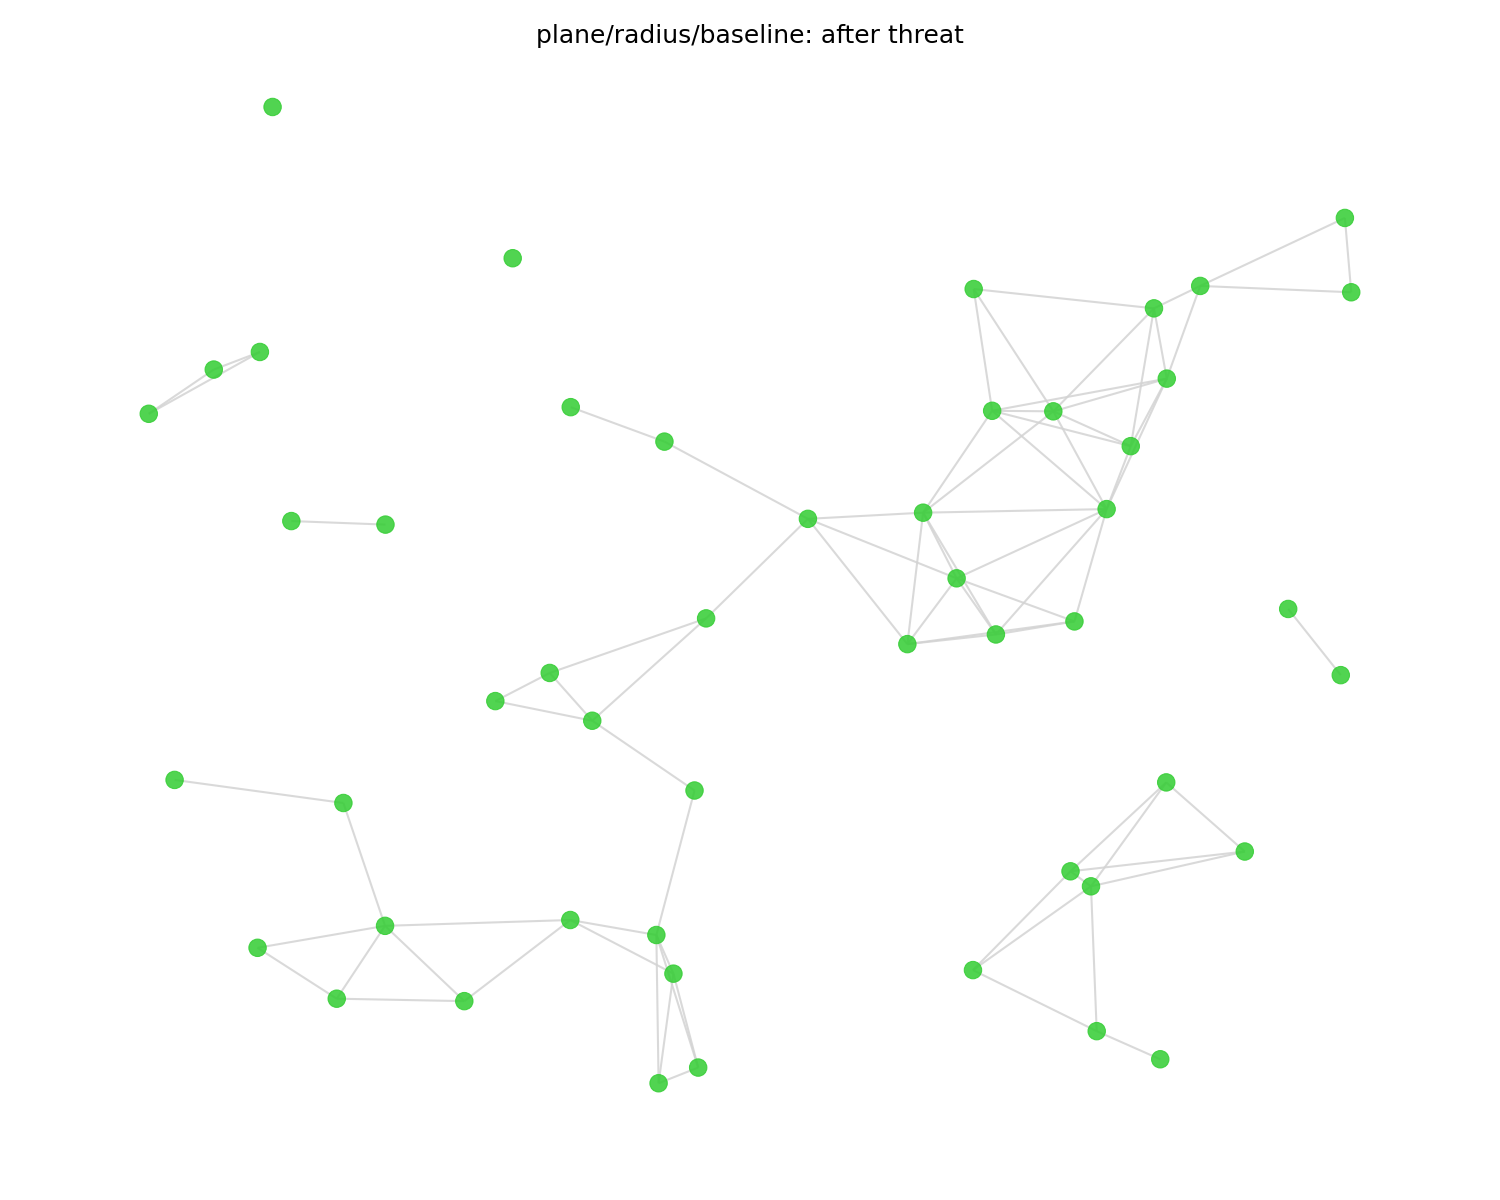

**rogue: after threat**

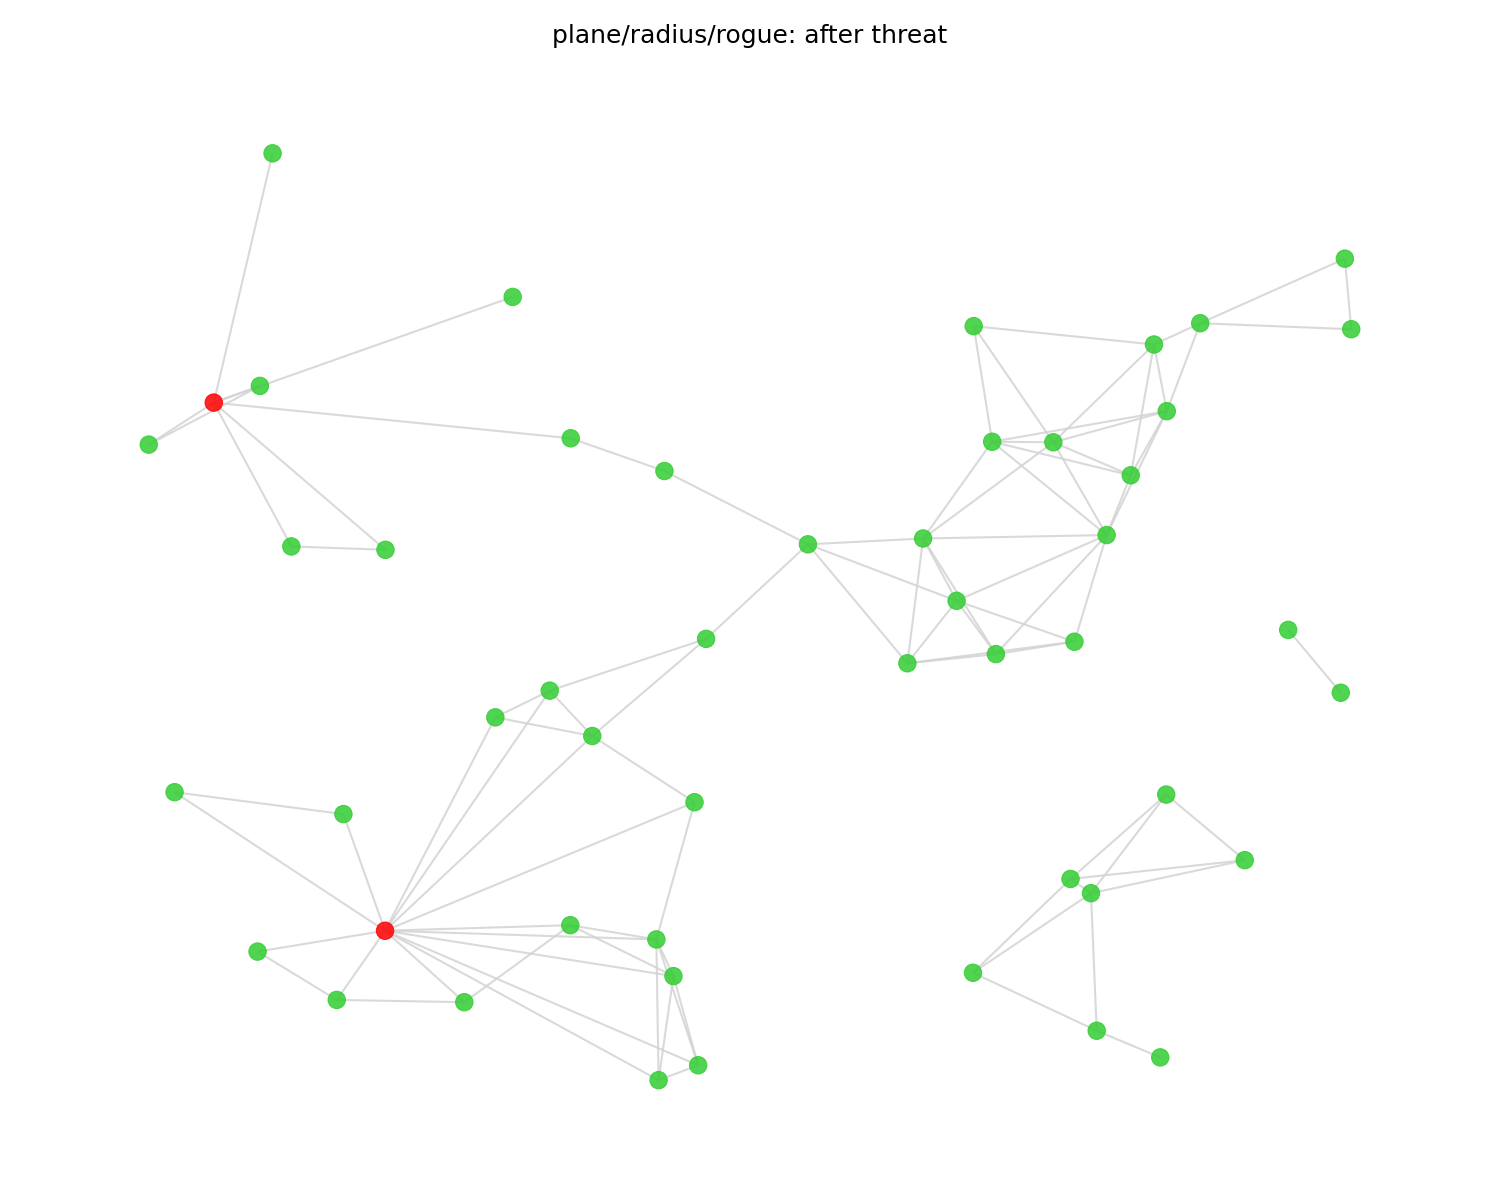

**flooding: after threat**

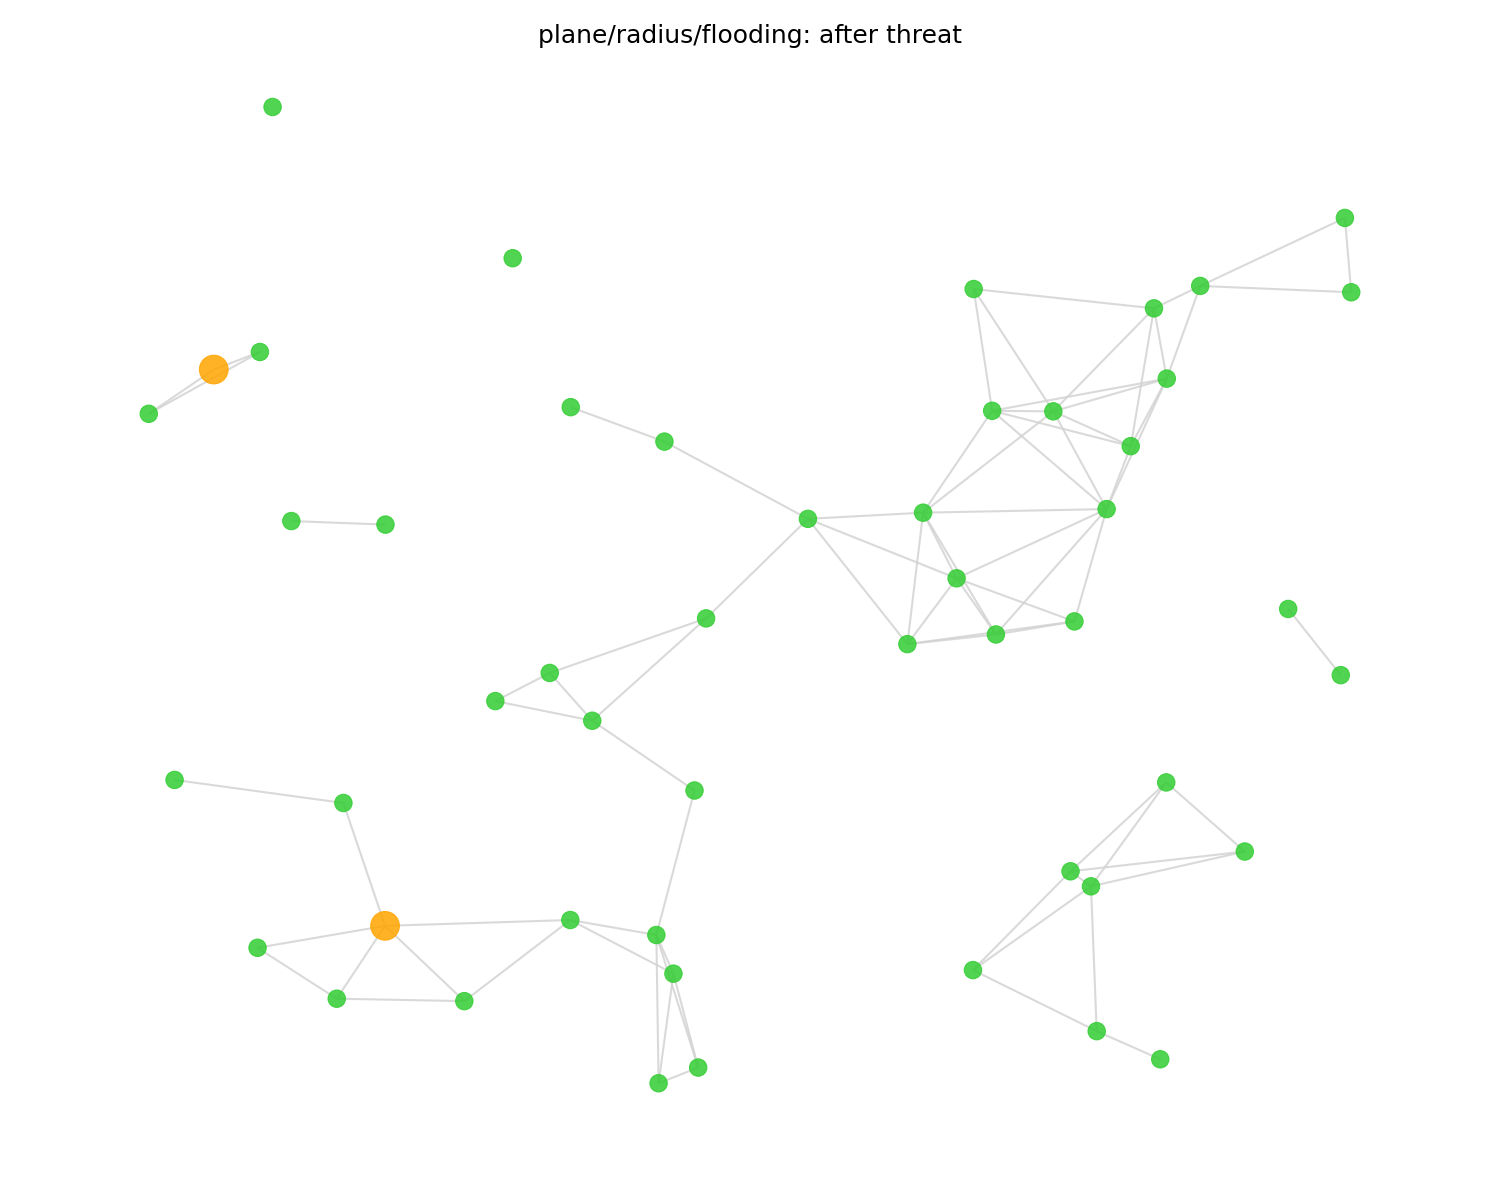

**isolation: after threat**

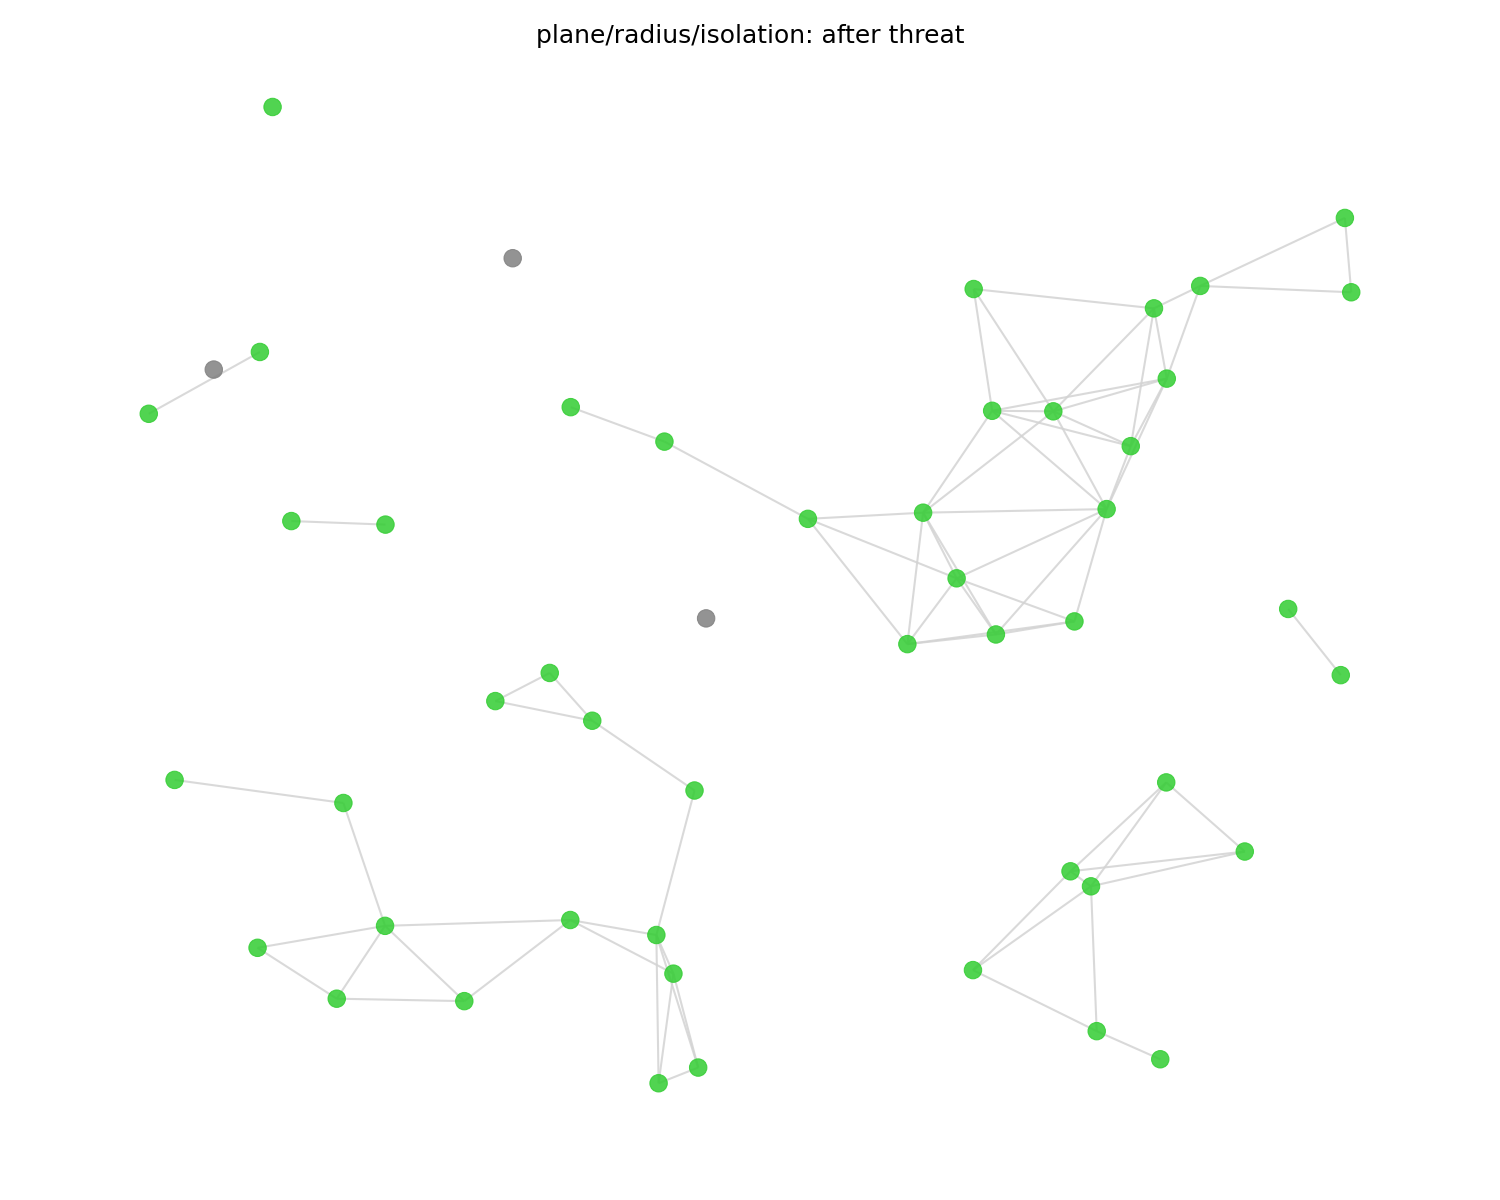

**spoofing: after threat**

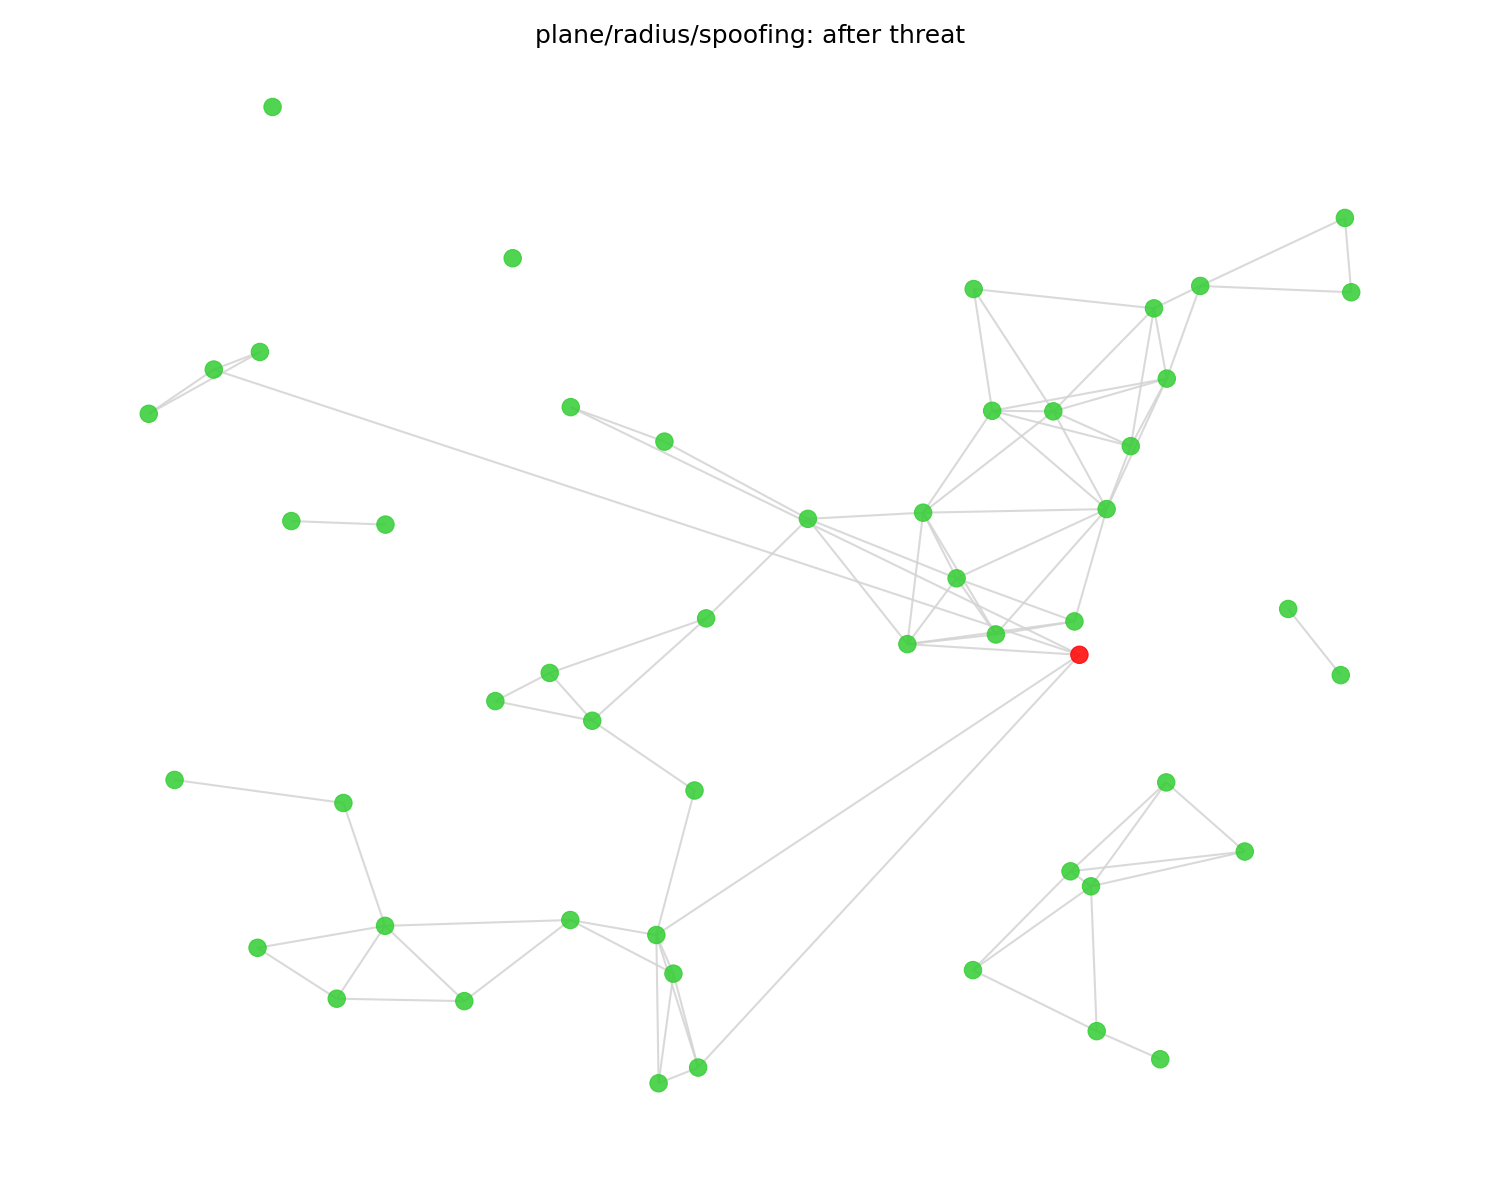

### PLANE / KNN

**baseline: after threat**

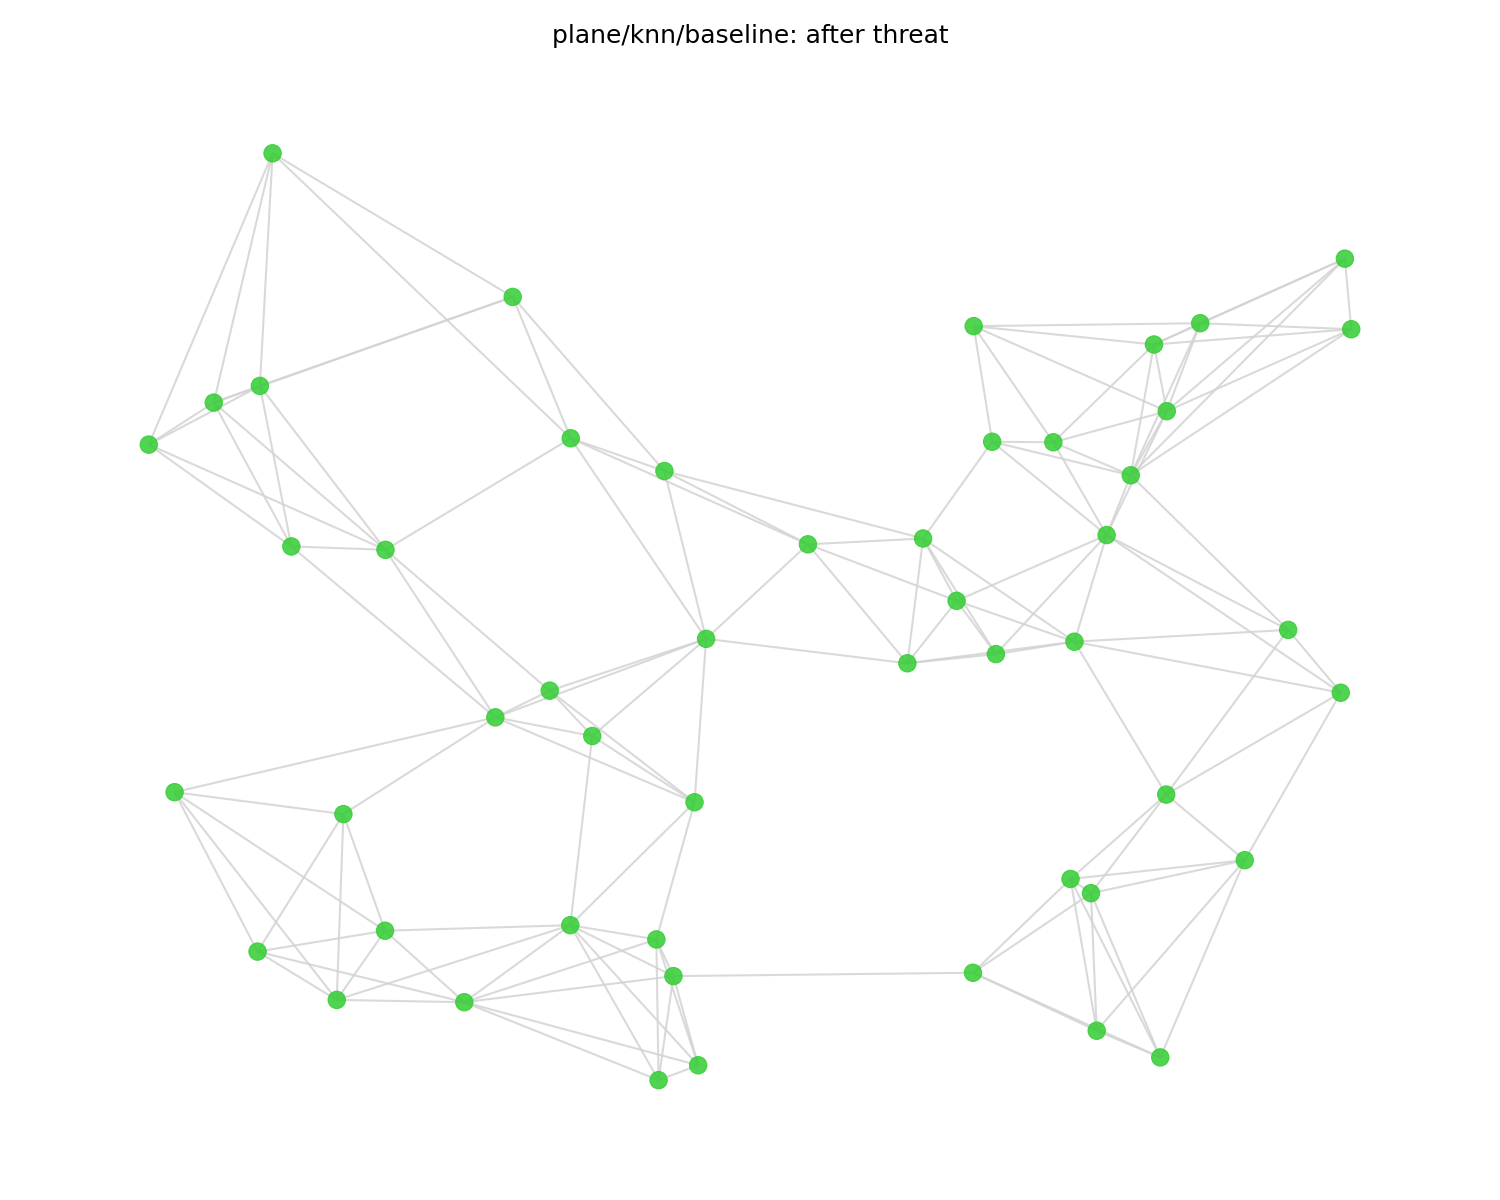

**rogue: after threat**

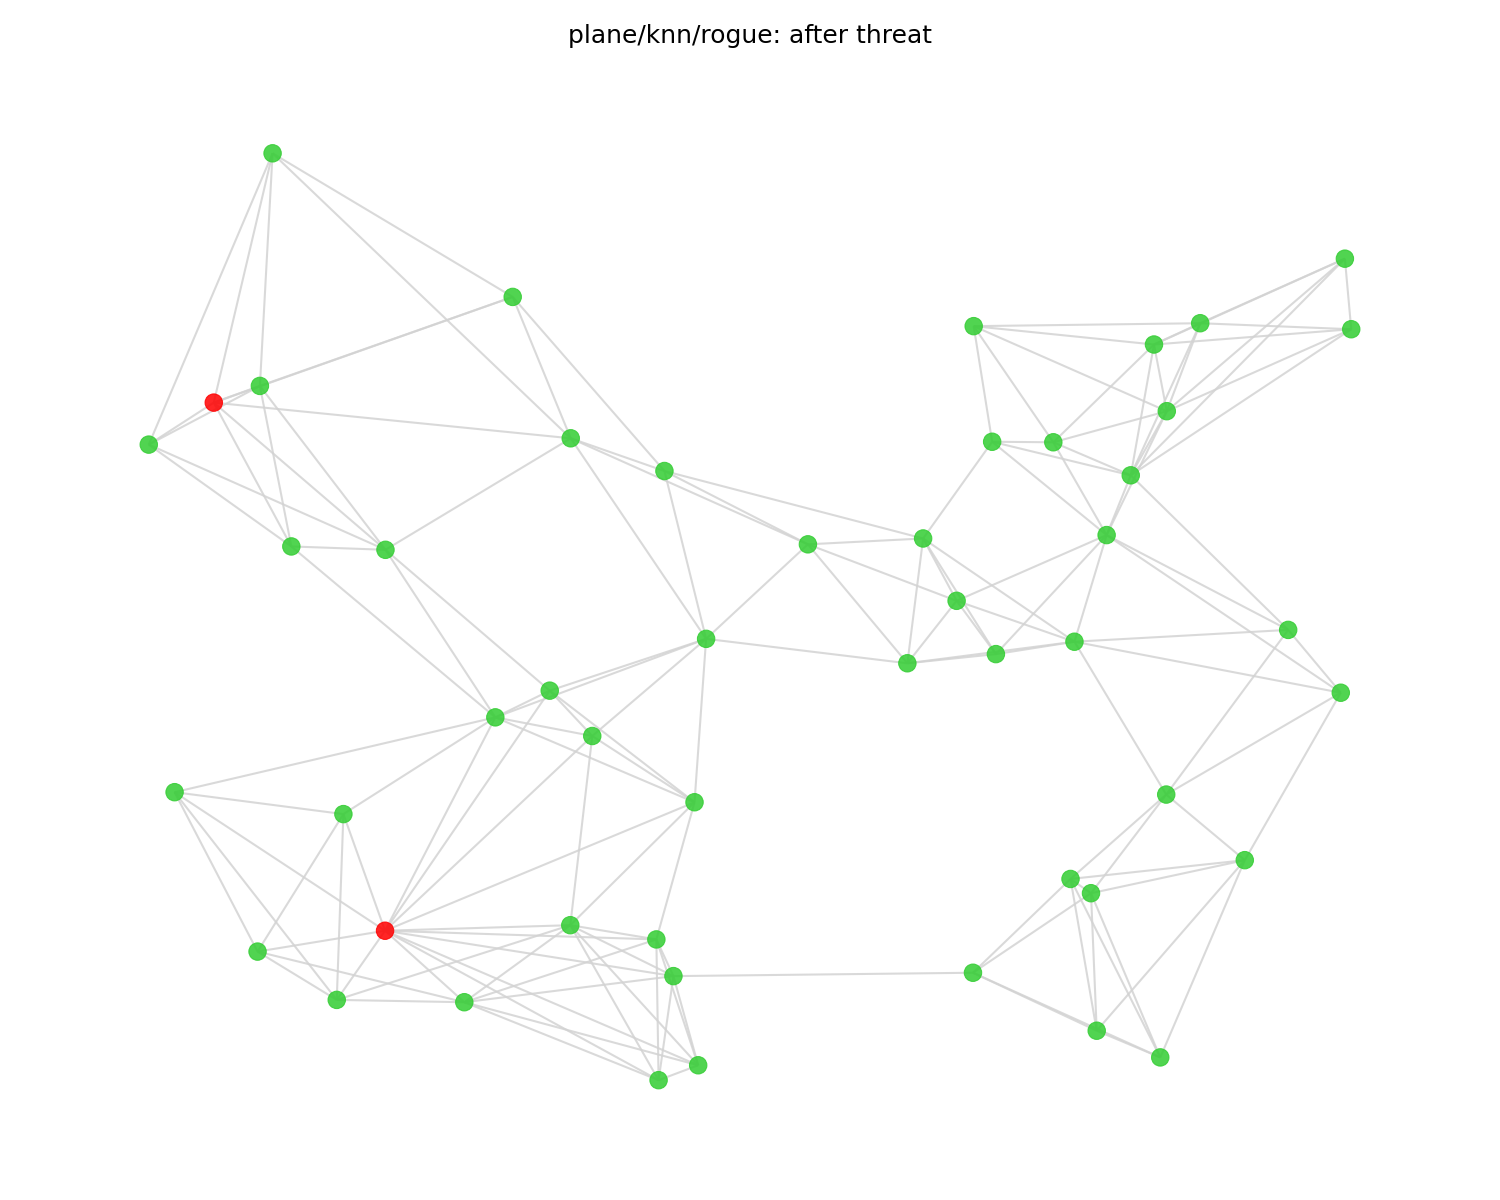

**flooding: after threat**

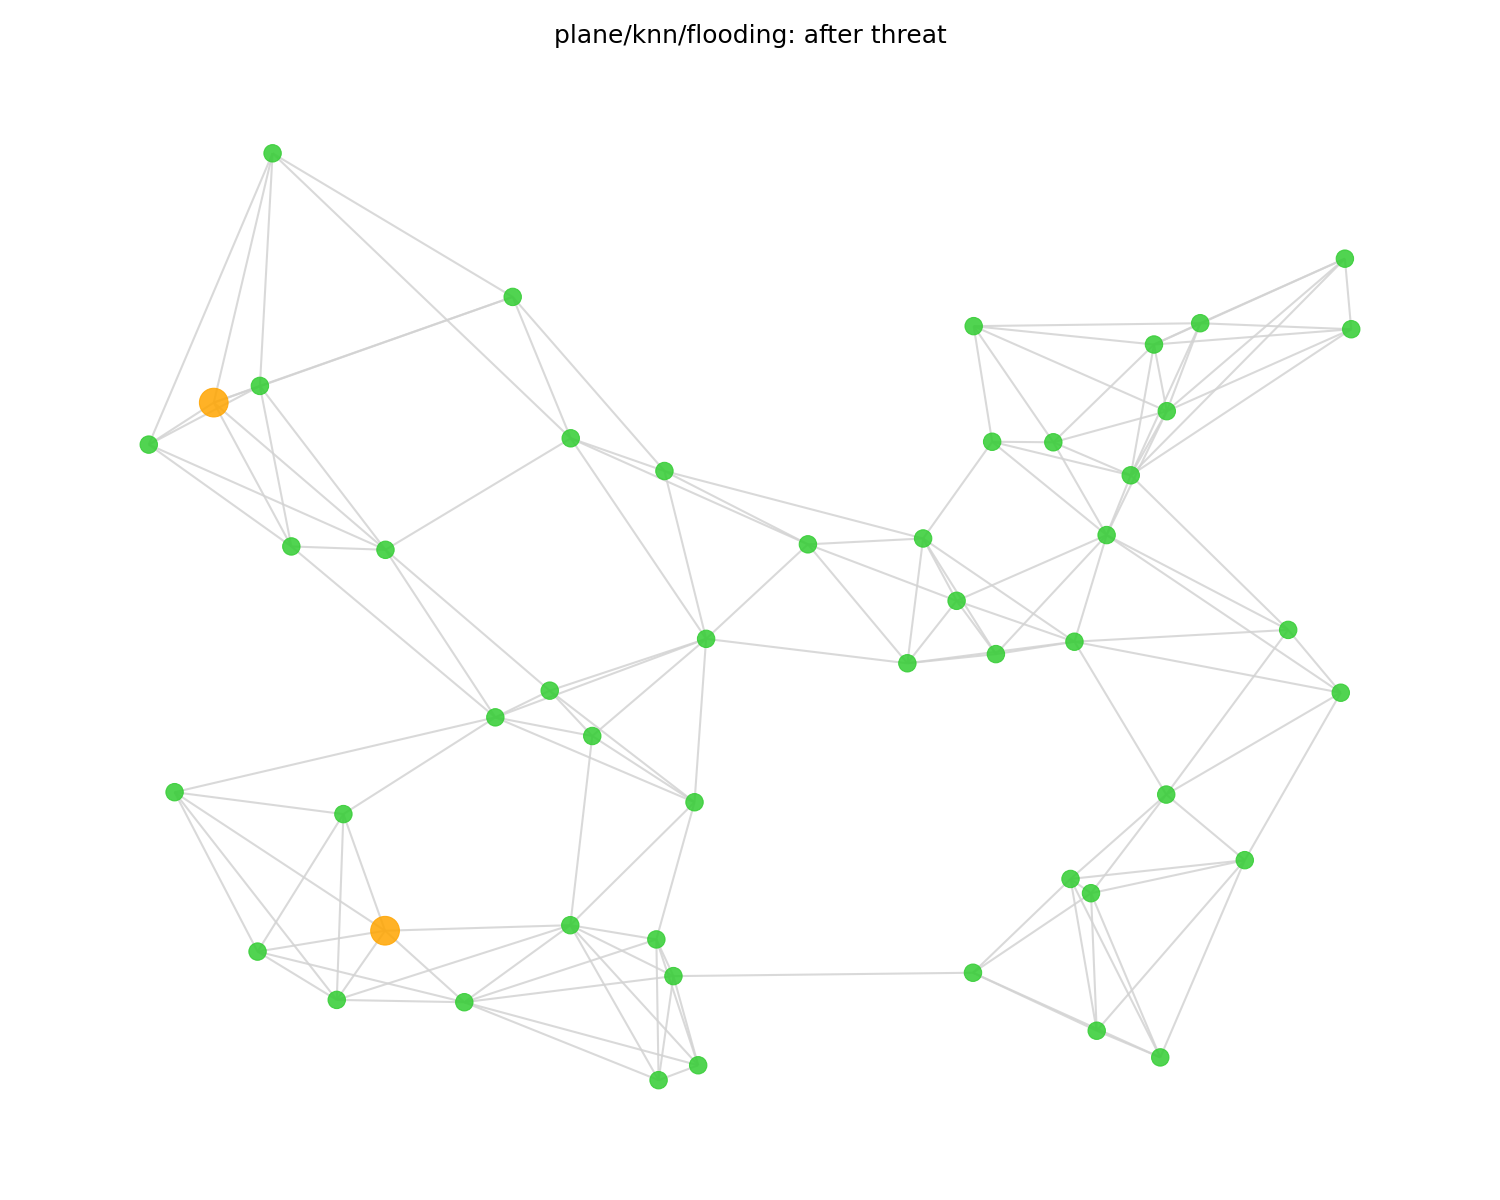

**isolation: after threat**

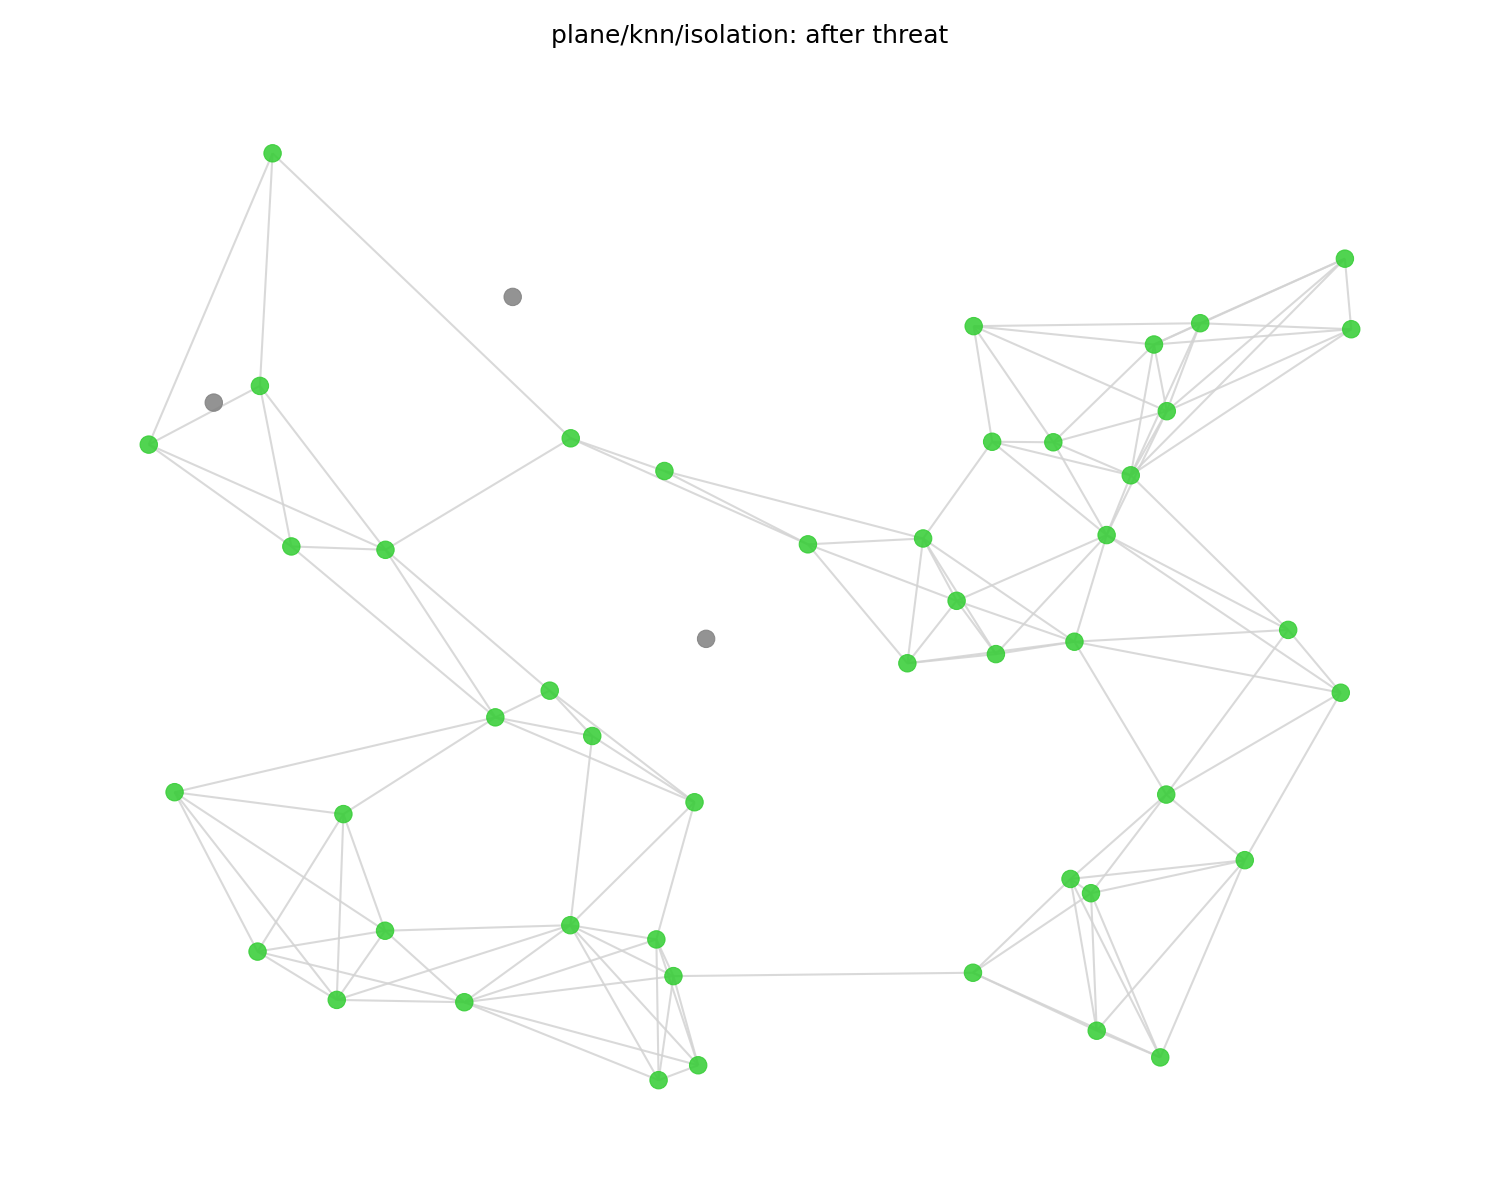

**spoofing: after threat**

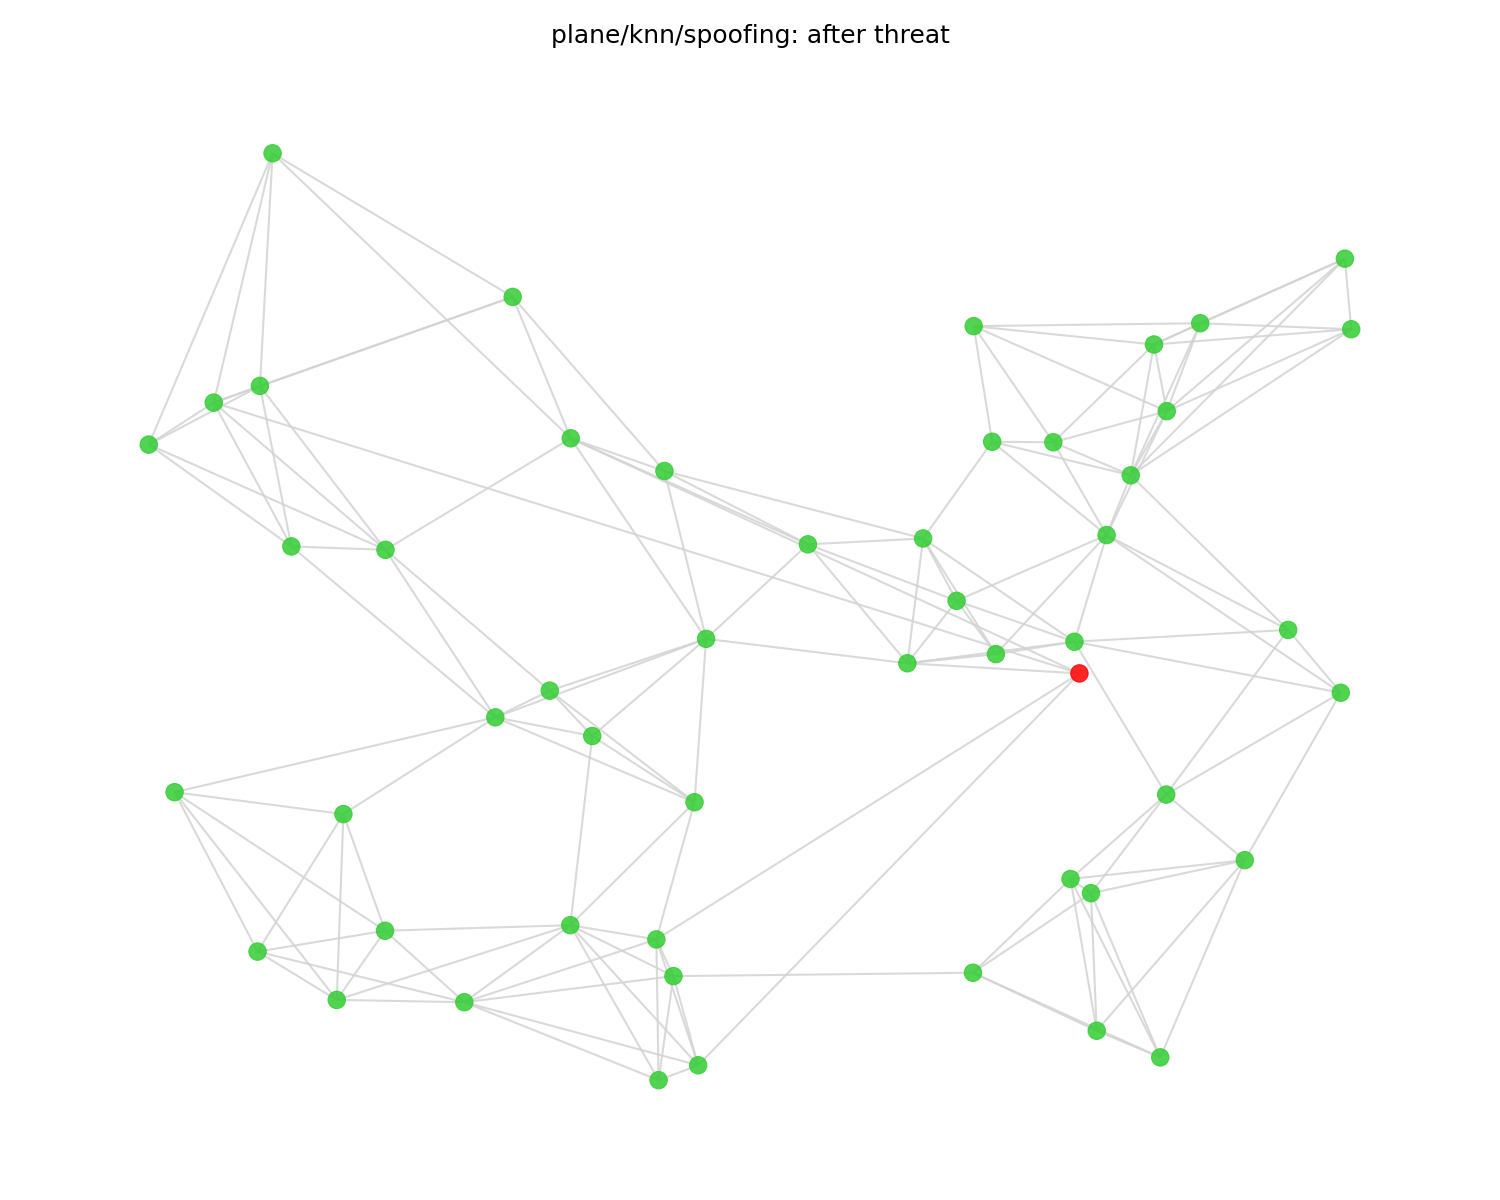

### GEO / RADIUS

**baseline: after threat**

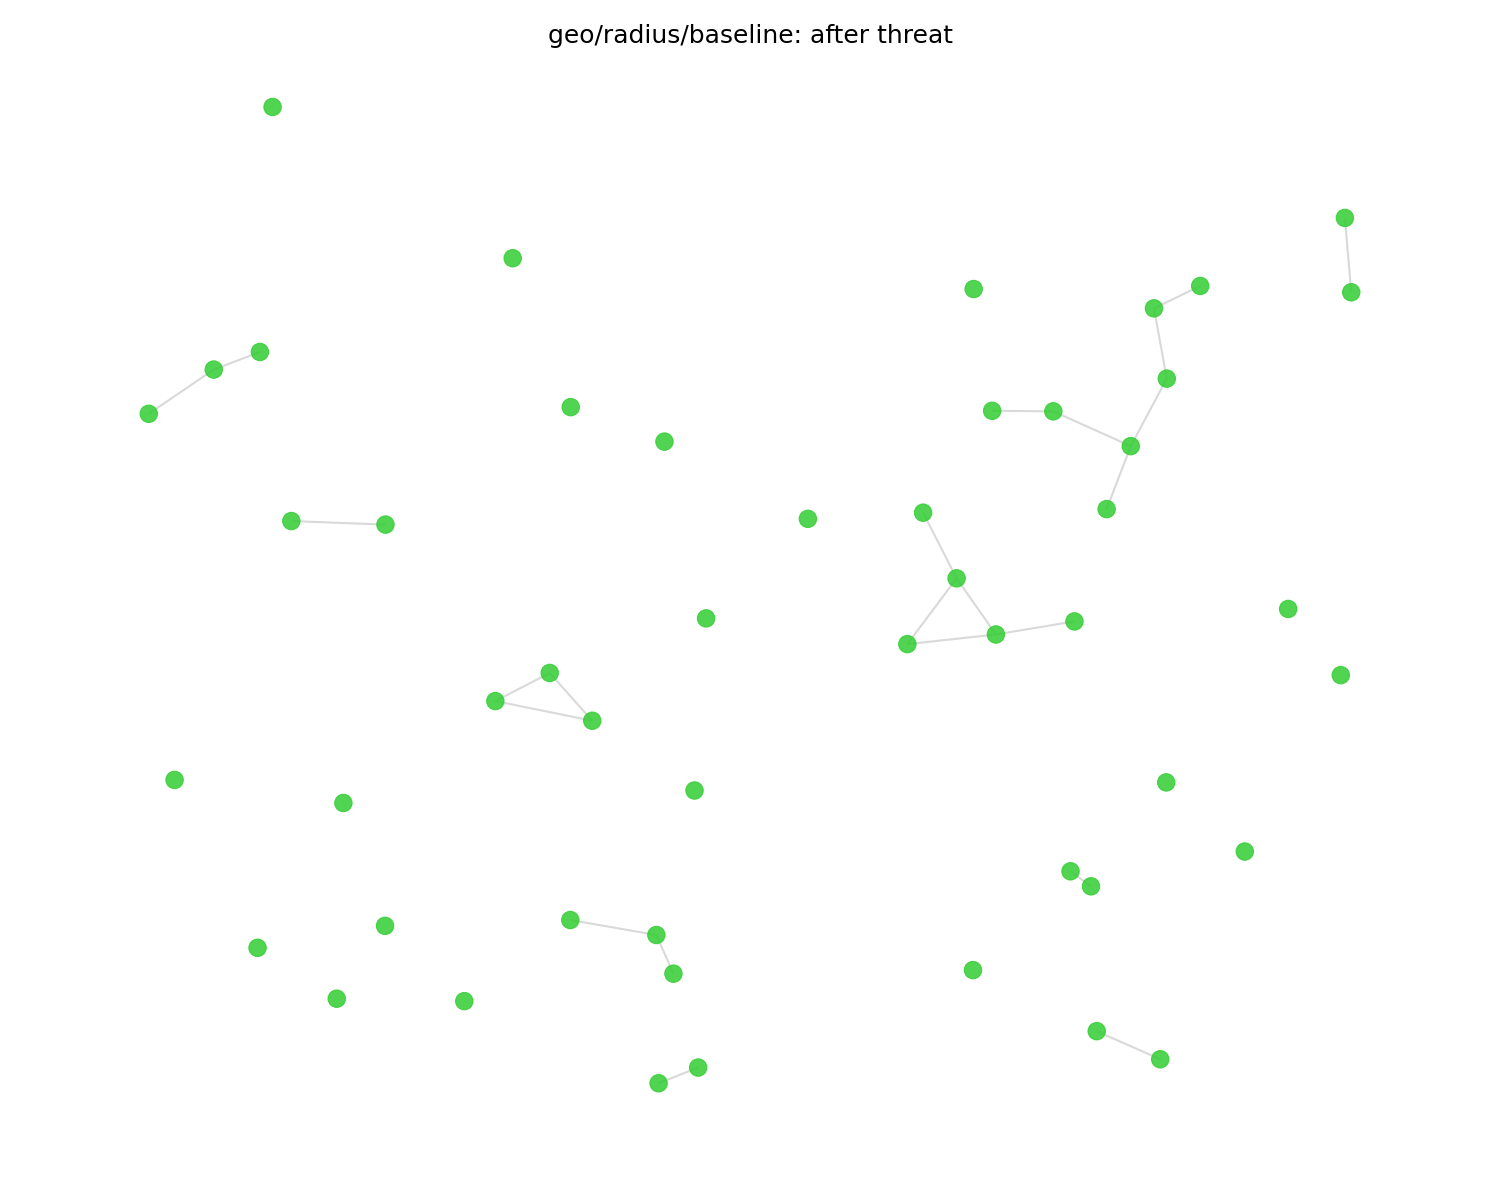

**rogue: after threat**

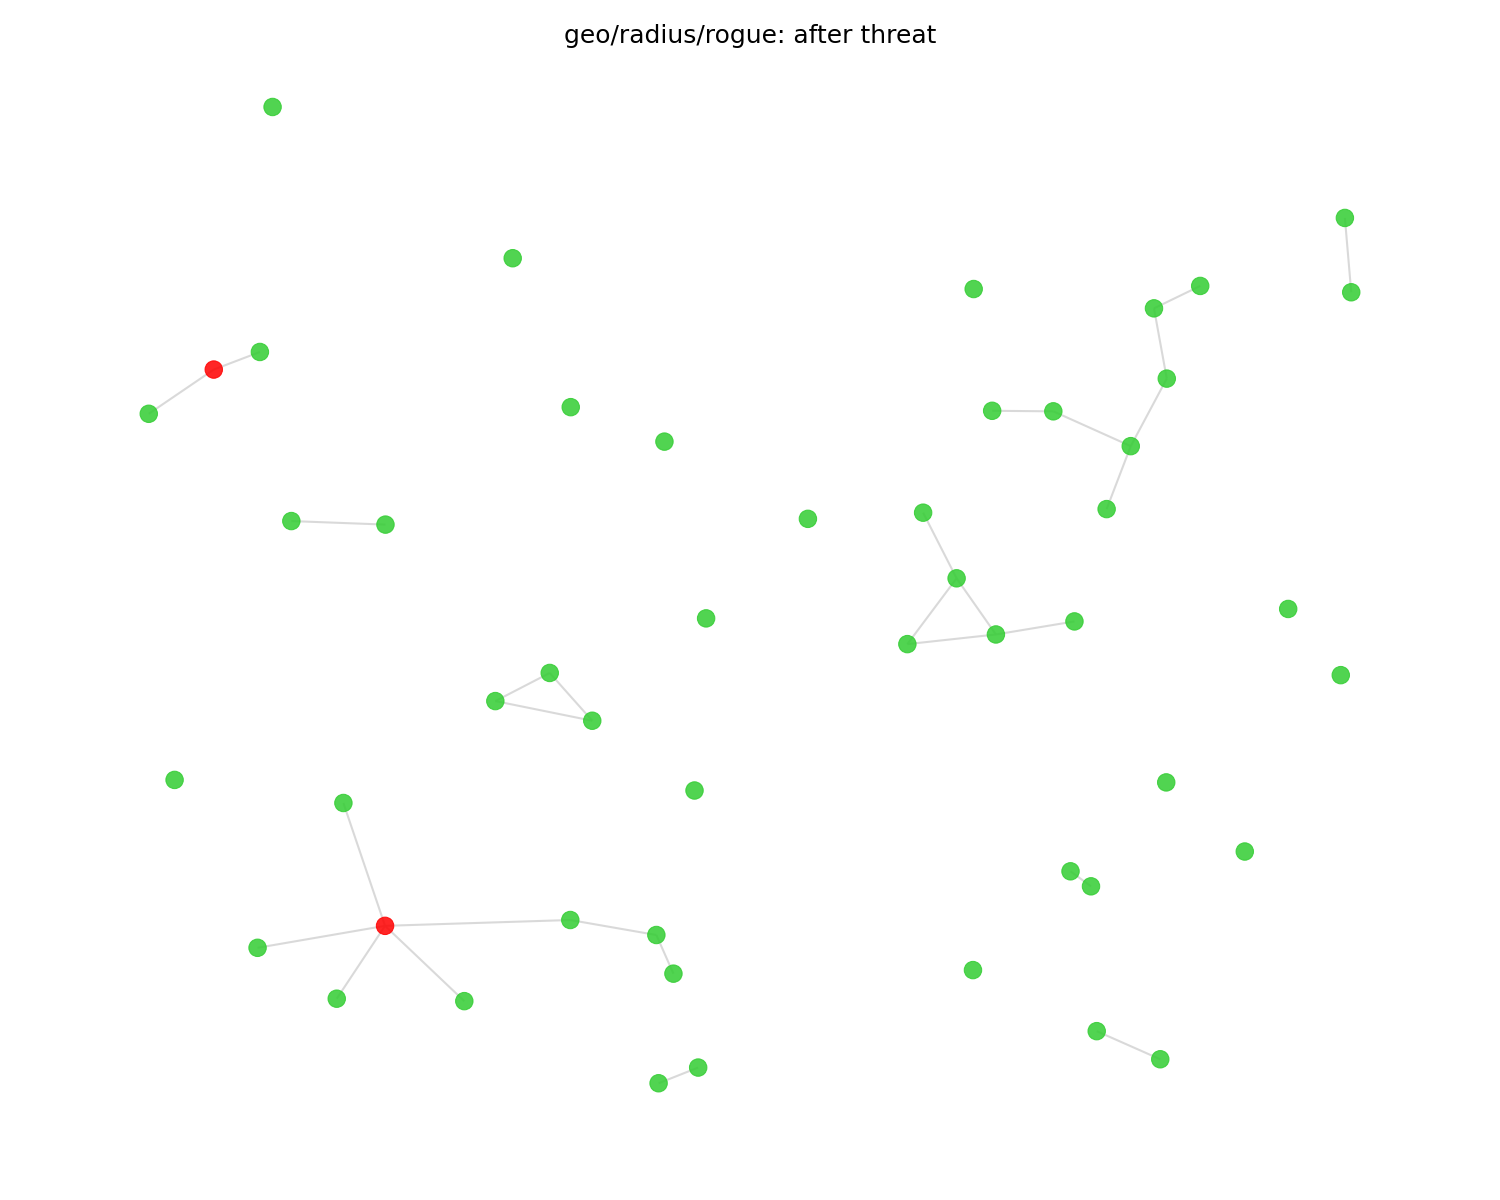

**flooding: after threat**

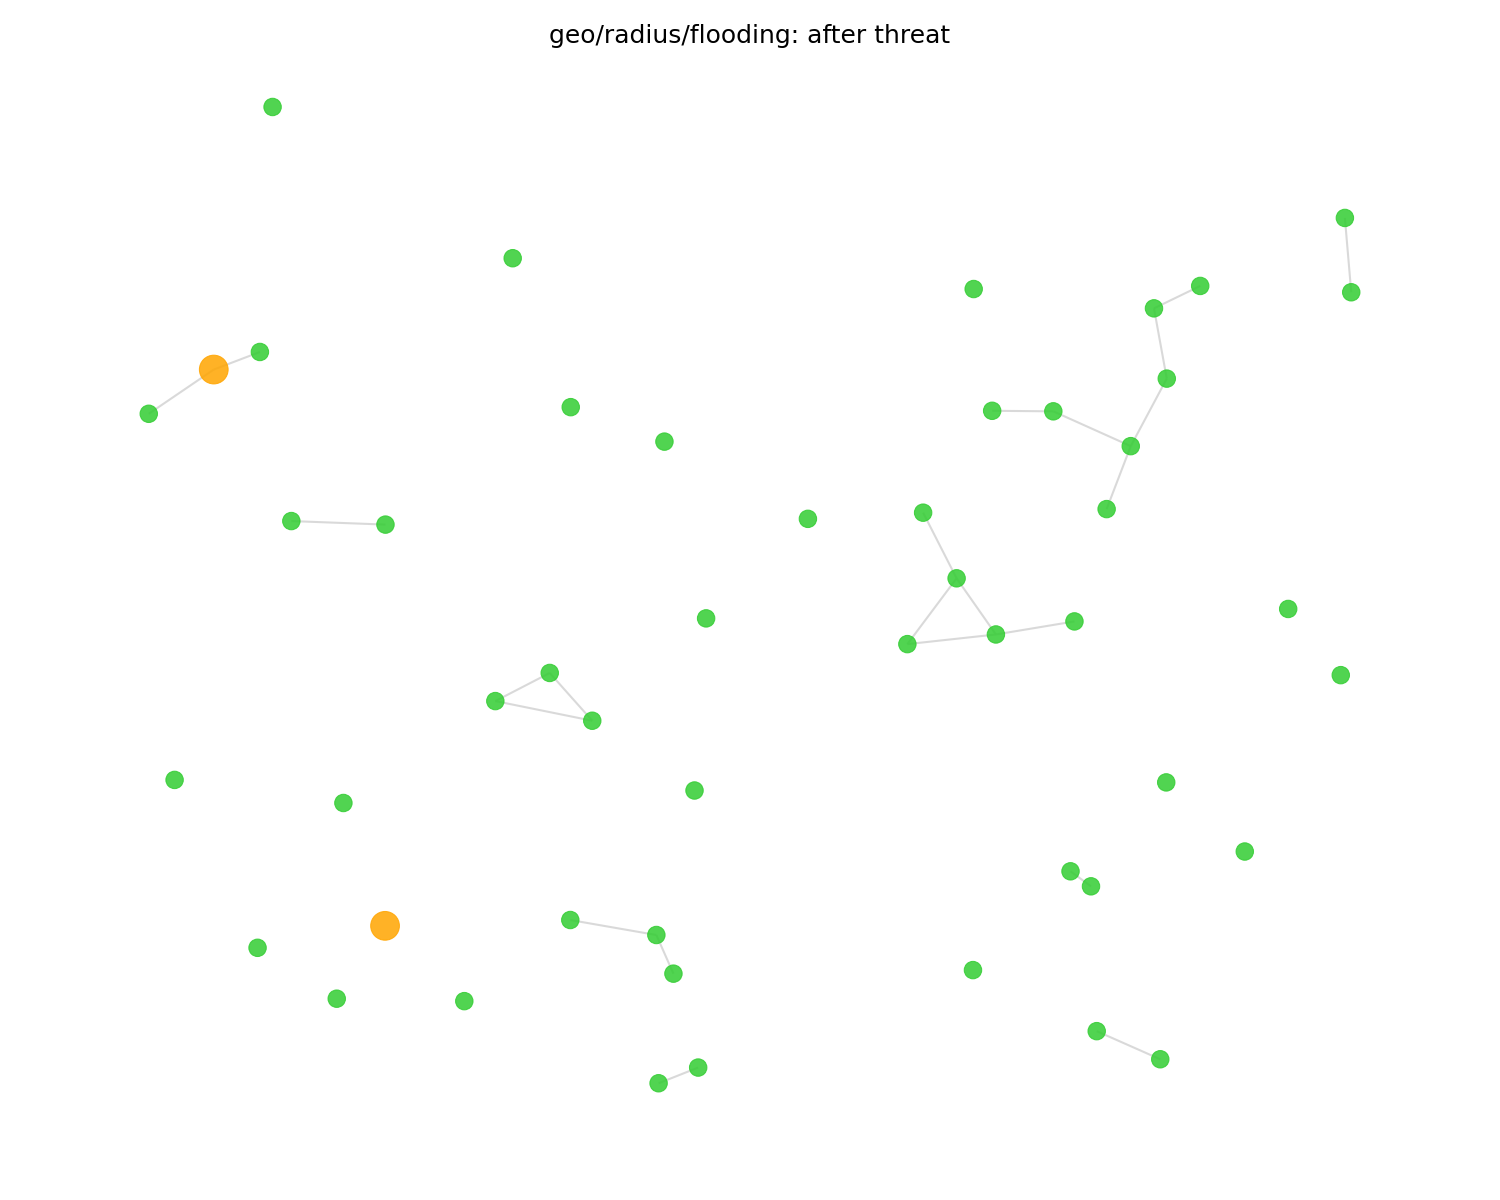

**isolation: after threat**

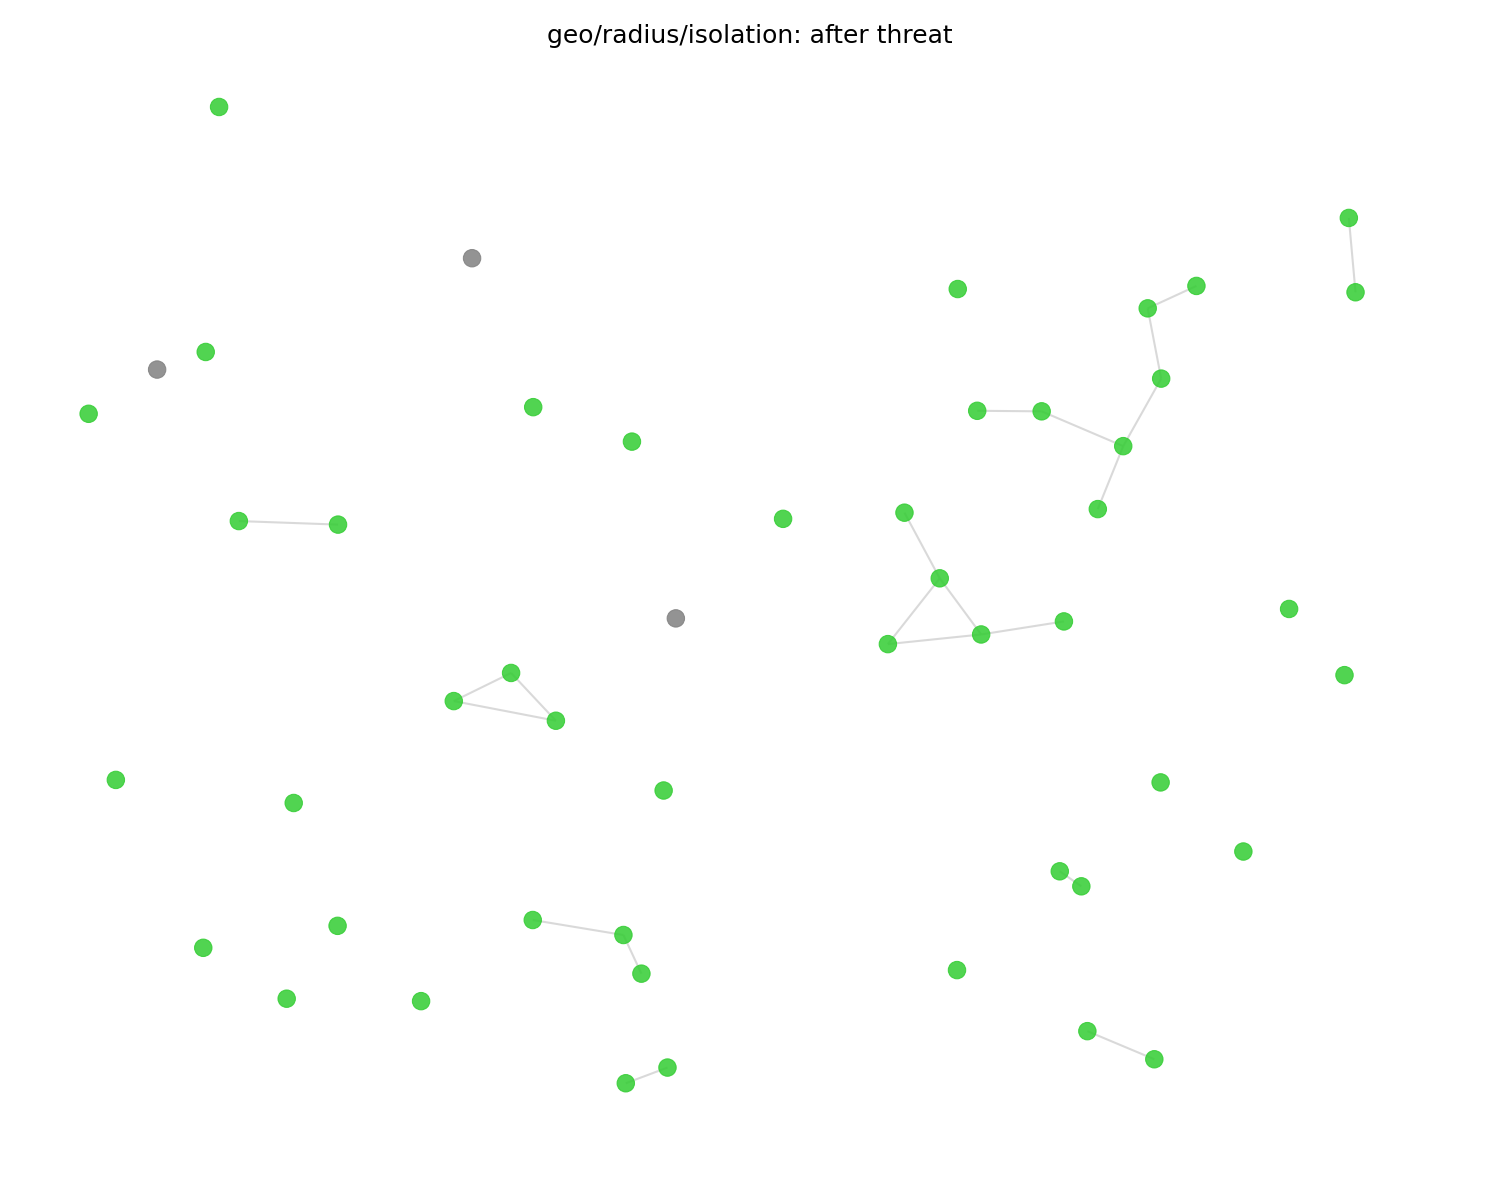

**spoofing: after threat**

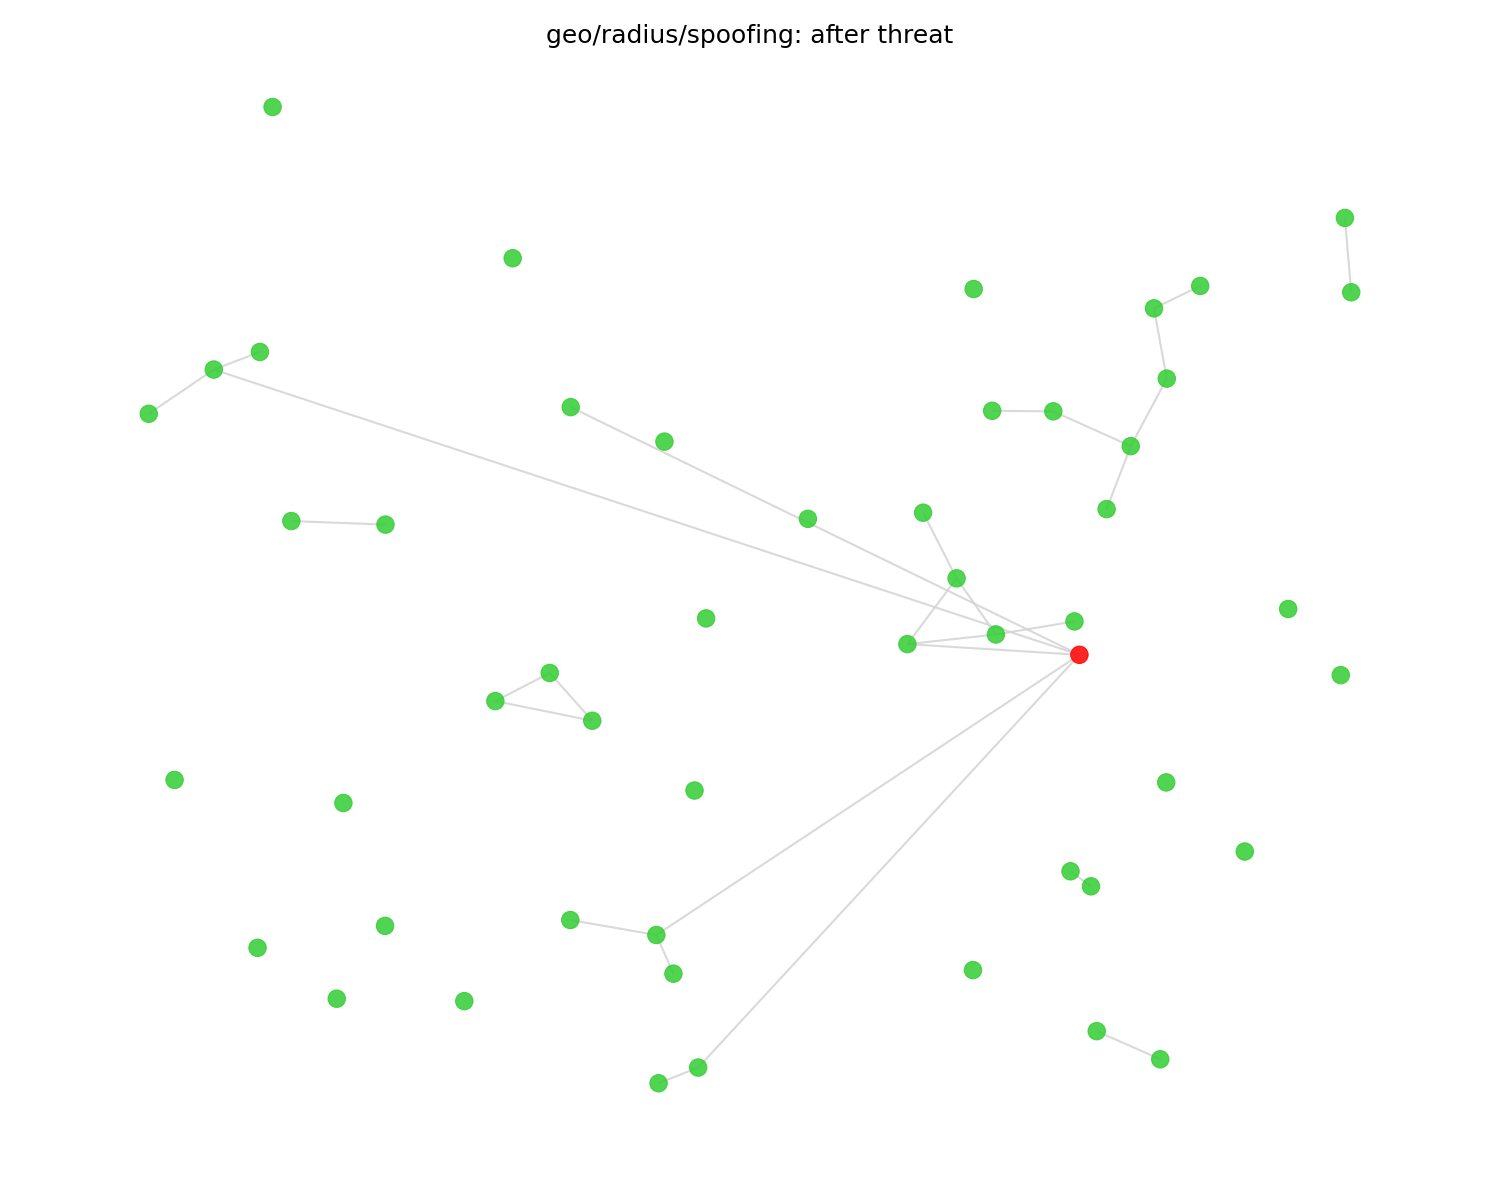

### GEO / KNN

**baseline: after threat**

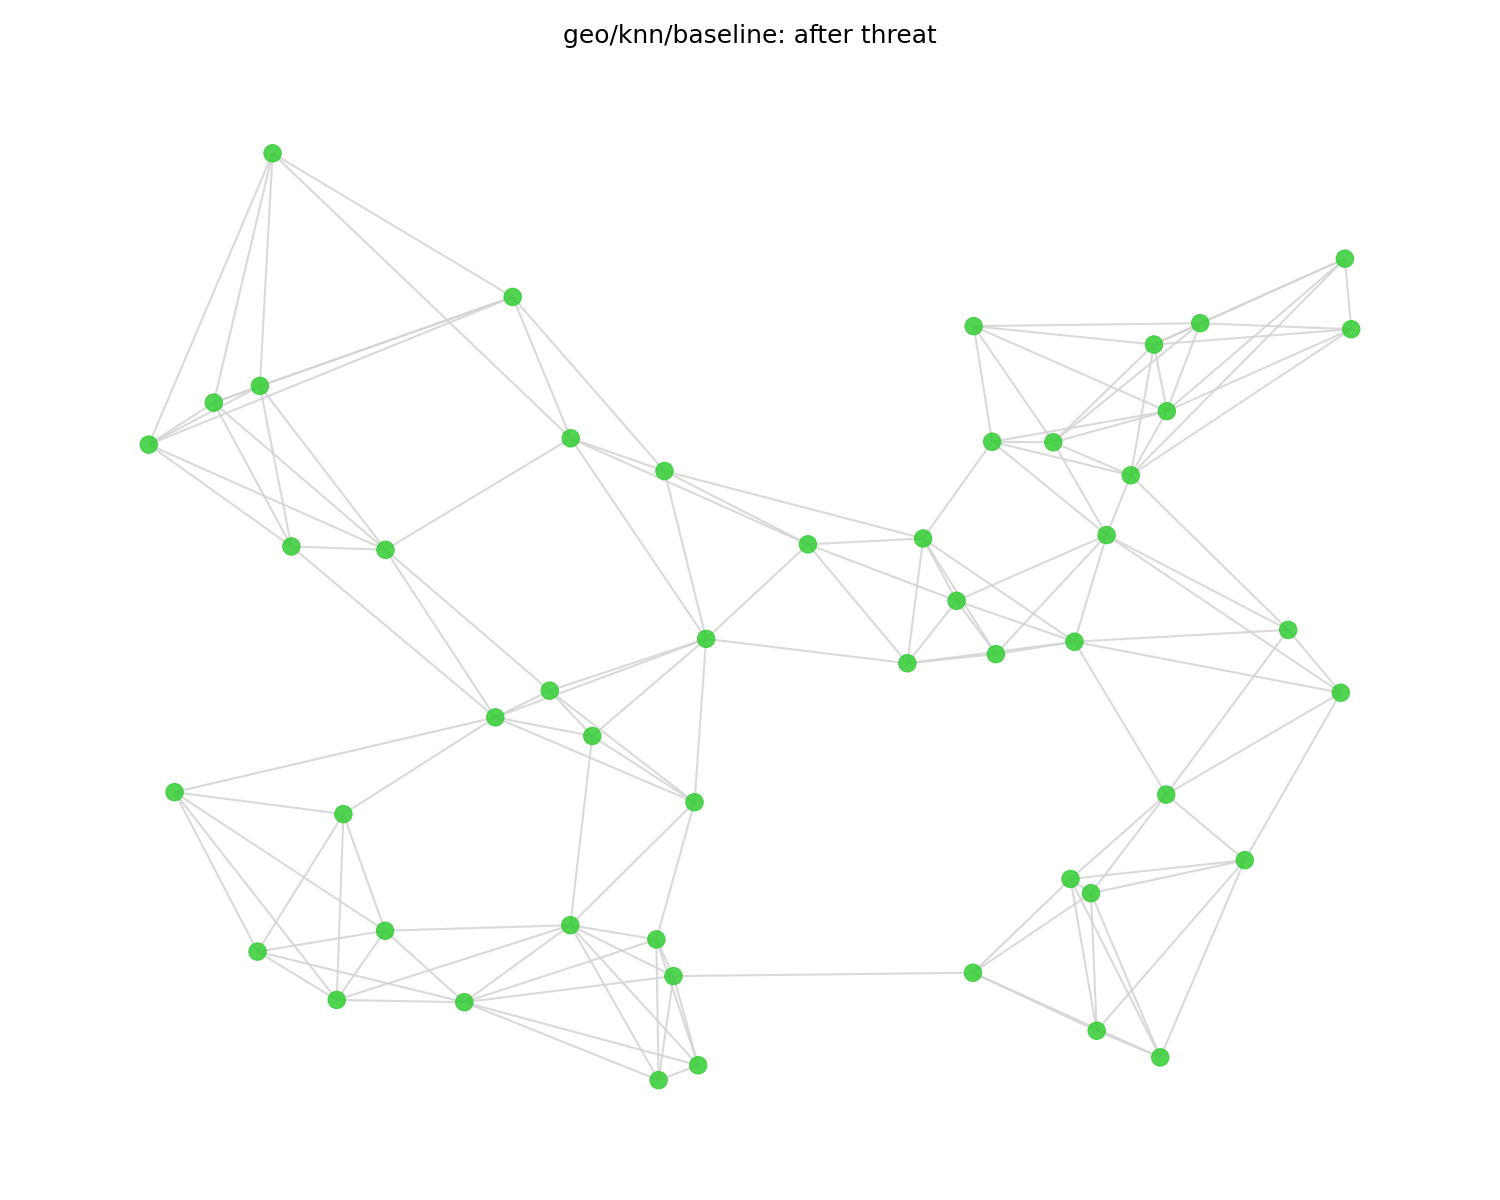

**rogue: after threat**

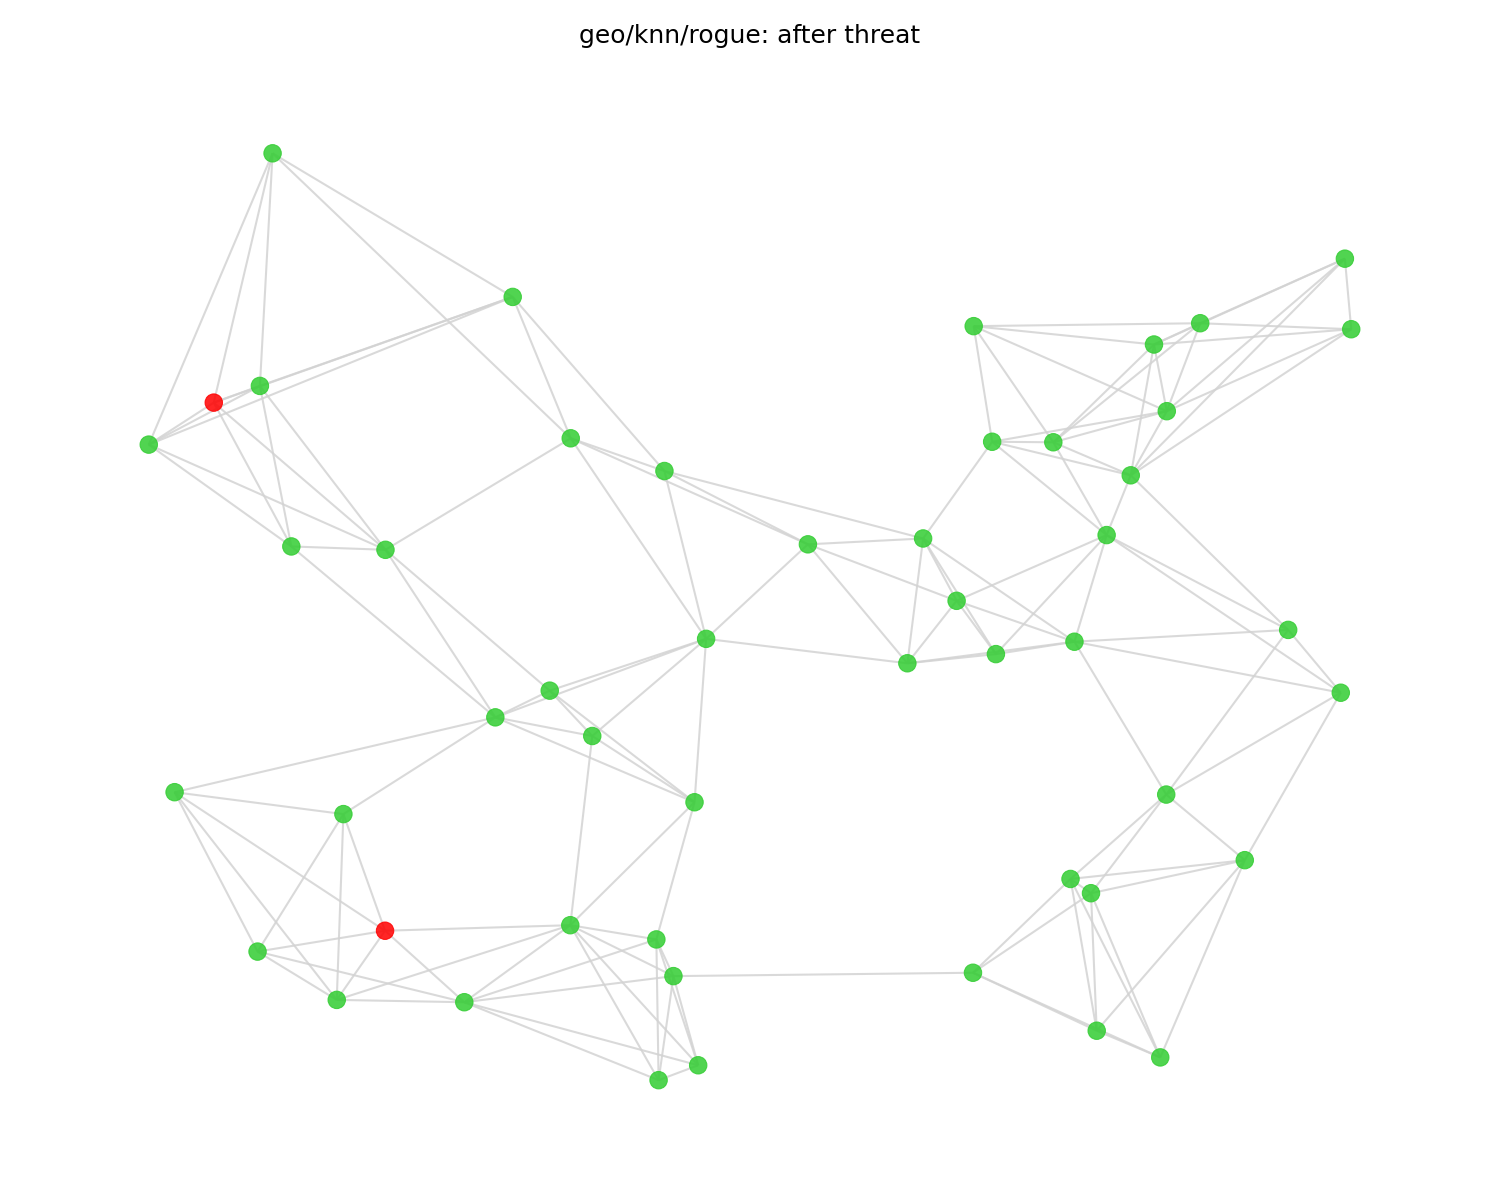

**flooding: after threat**

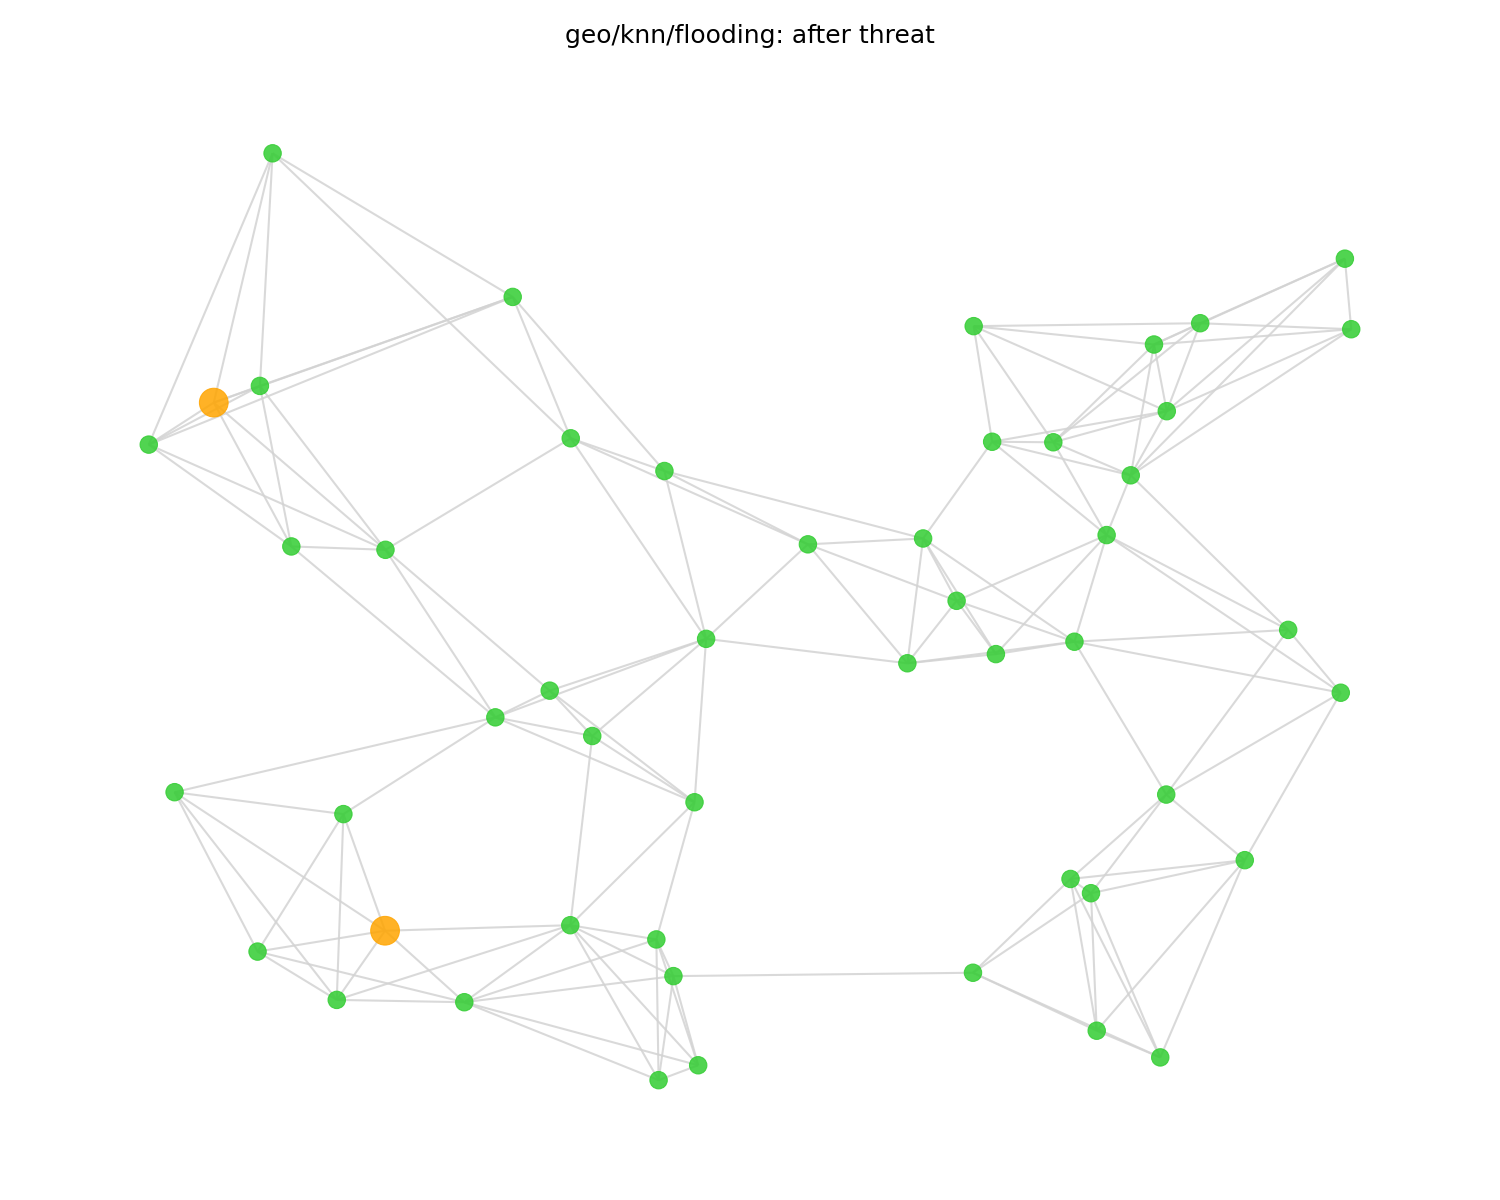

**isolation: after threat**

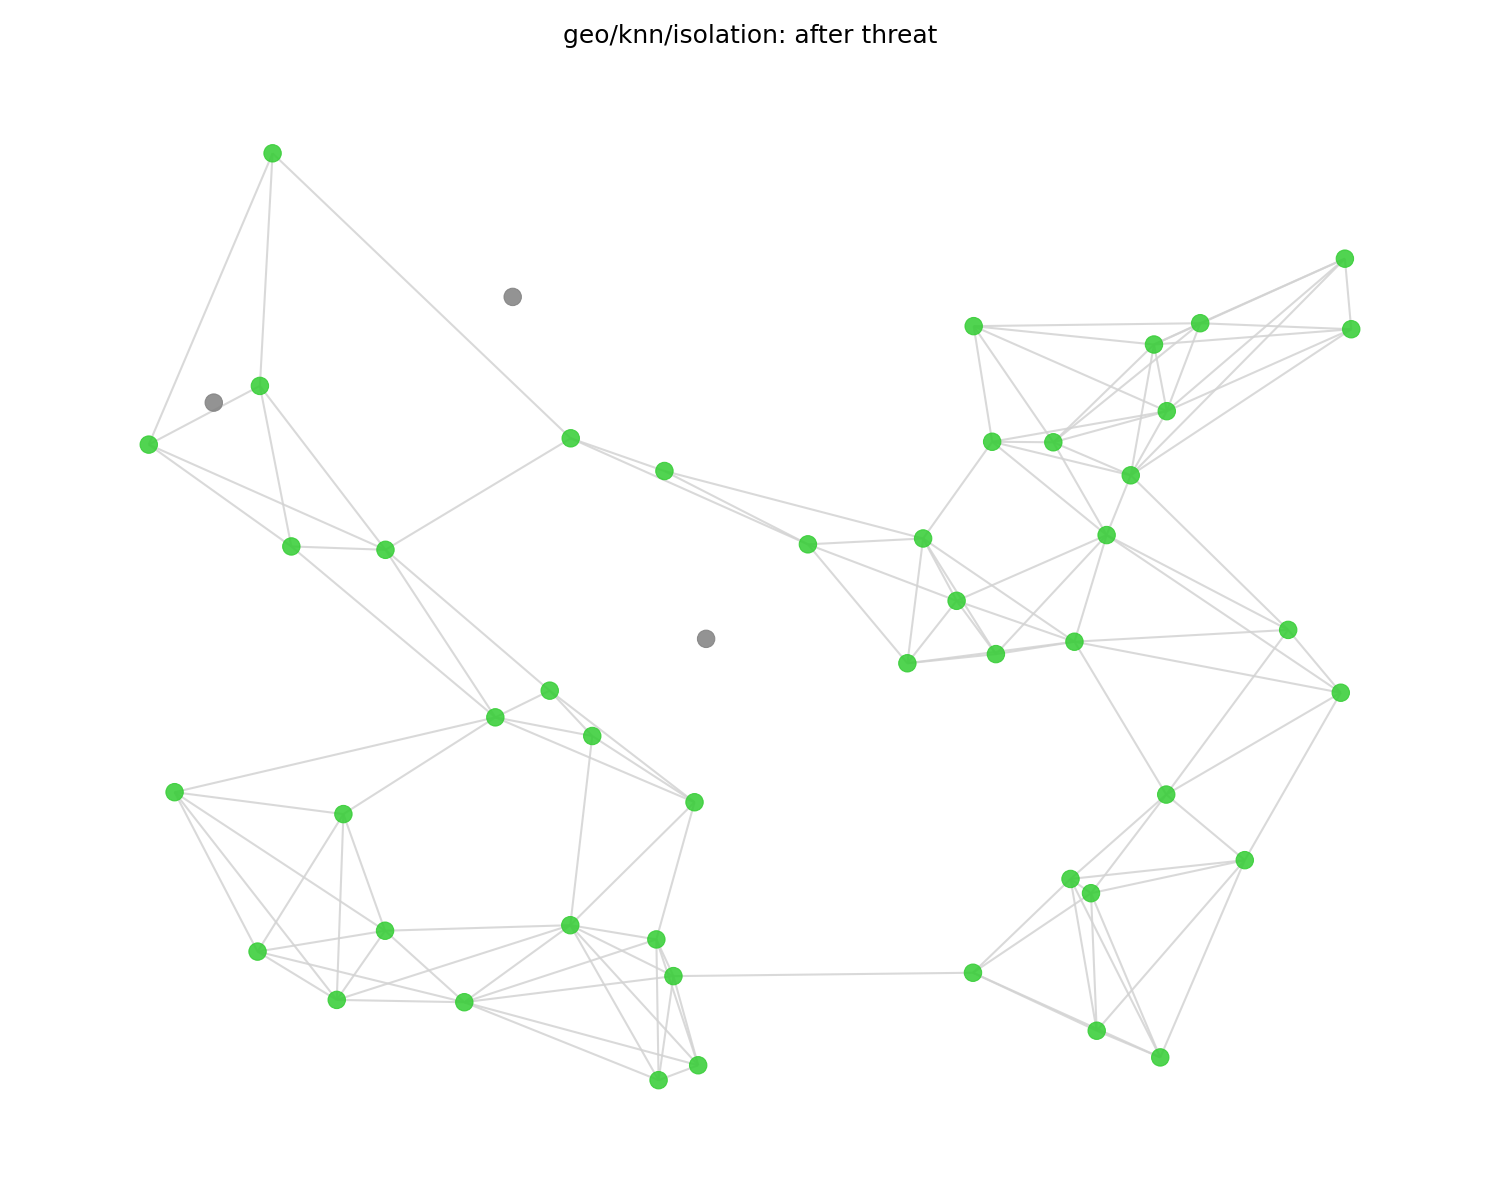

**spoofing: after threat**

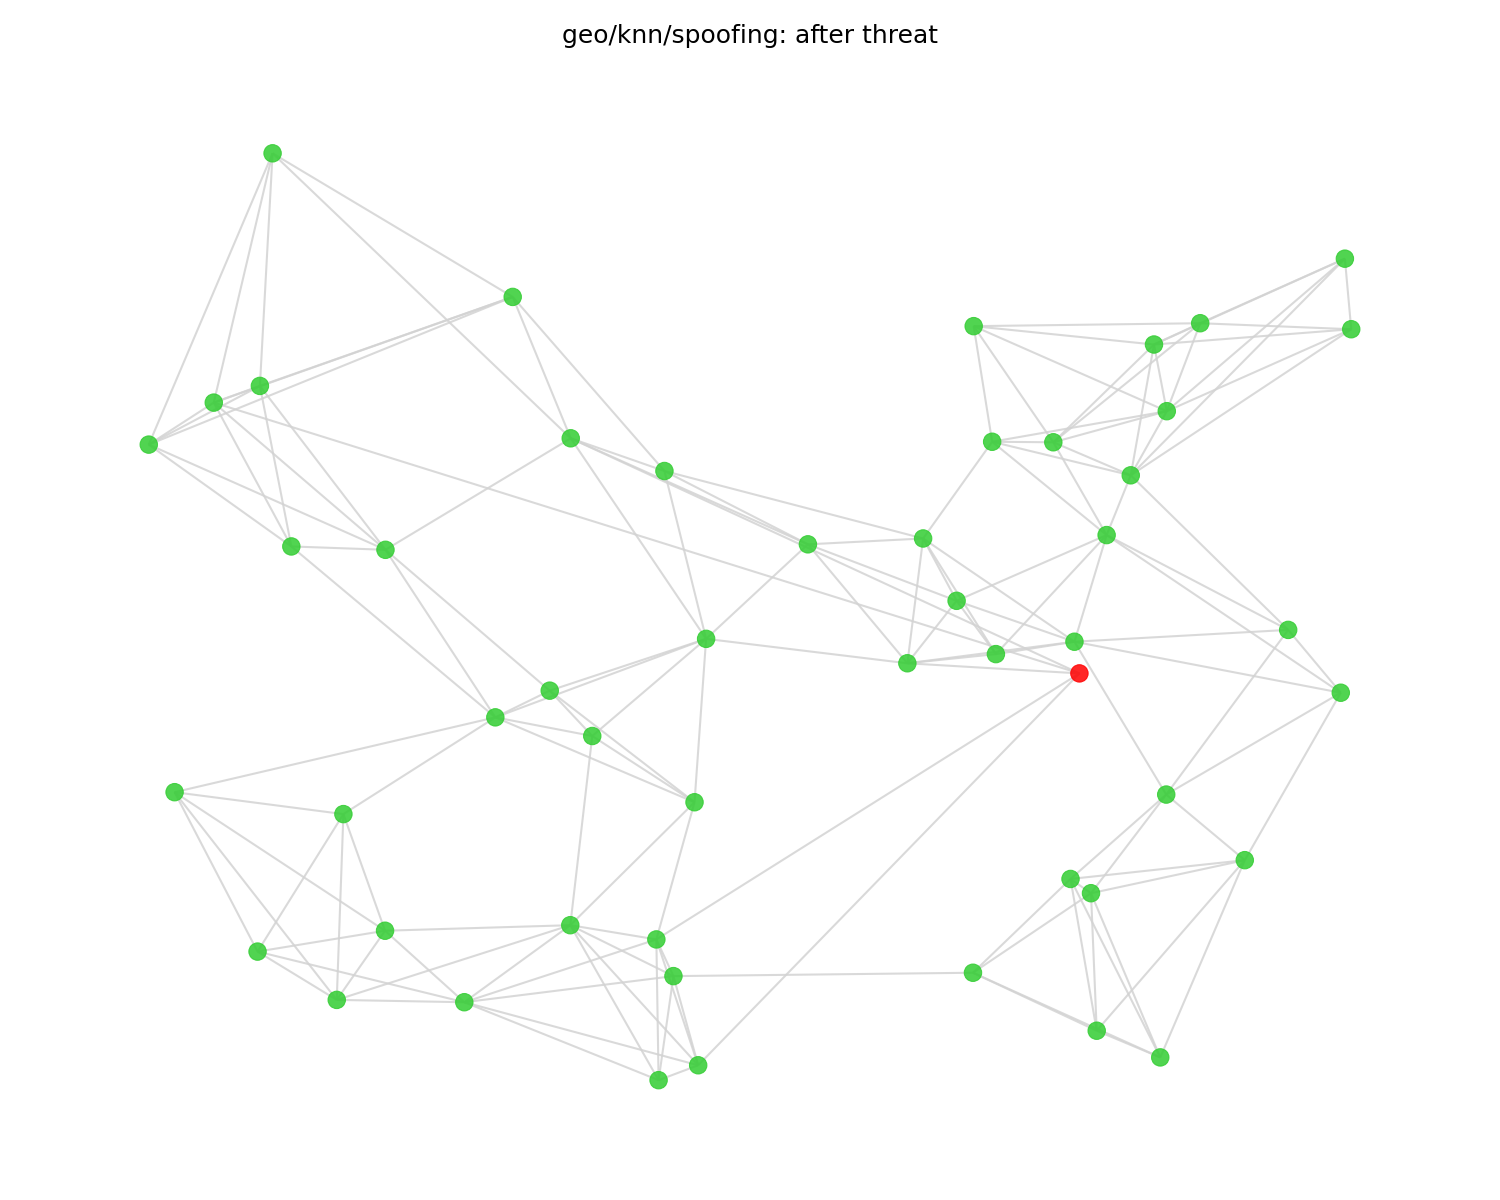

In [6]:
for coord in RUN_COORDS:
    root = coord_root(coord)
    for graph in GRAPH_TYPES:
        display(Markdown(f"### {coord.upper()} / {graph.upper()}"))
        for scenario in SCENARIOS:
            img_path = root / "figures" / graph / f"{scenario}_after.png"
            if img_path.exists():
                display(Markdown(f"**{scenario}: after threat**"))
                display(Image(filename=str(img_path), width=650))
            else:
                print("Файл не найден:", img_path)

## 5. Боксплоты устойчивости

### PLANE — stability boxplots

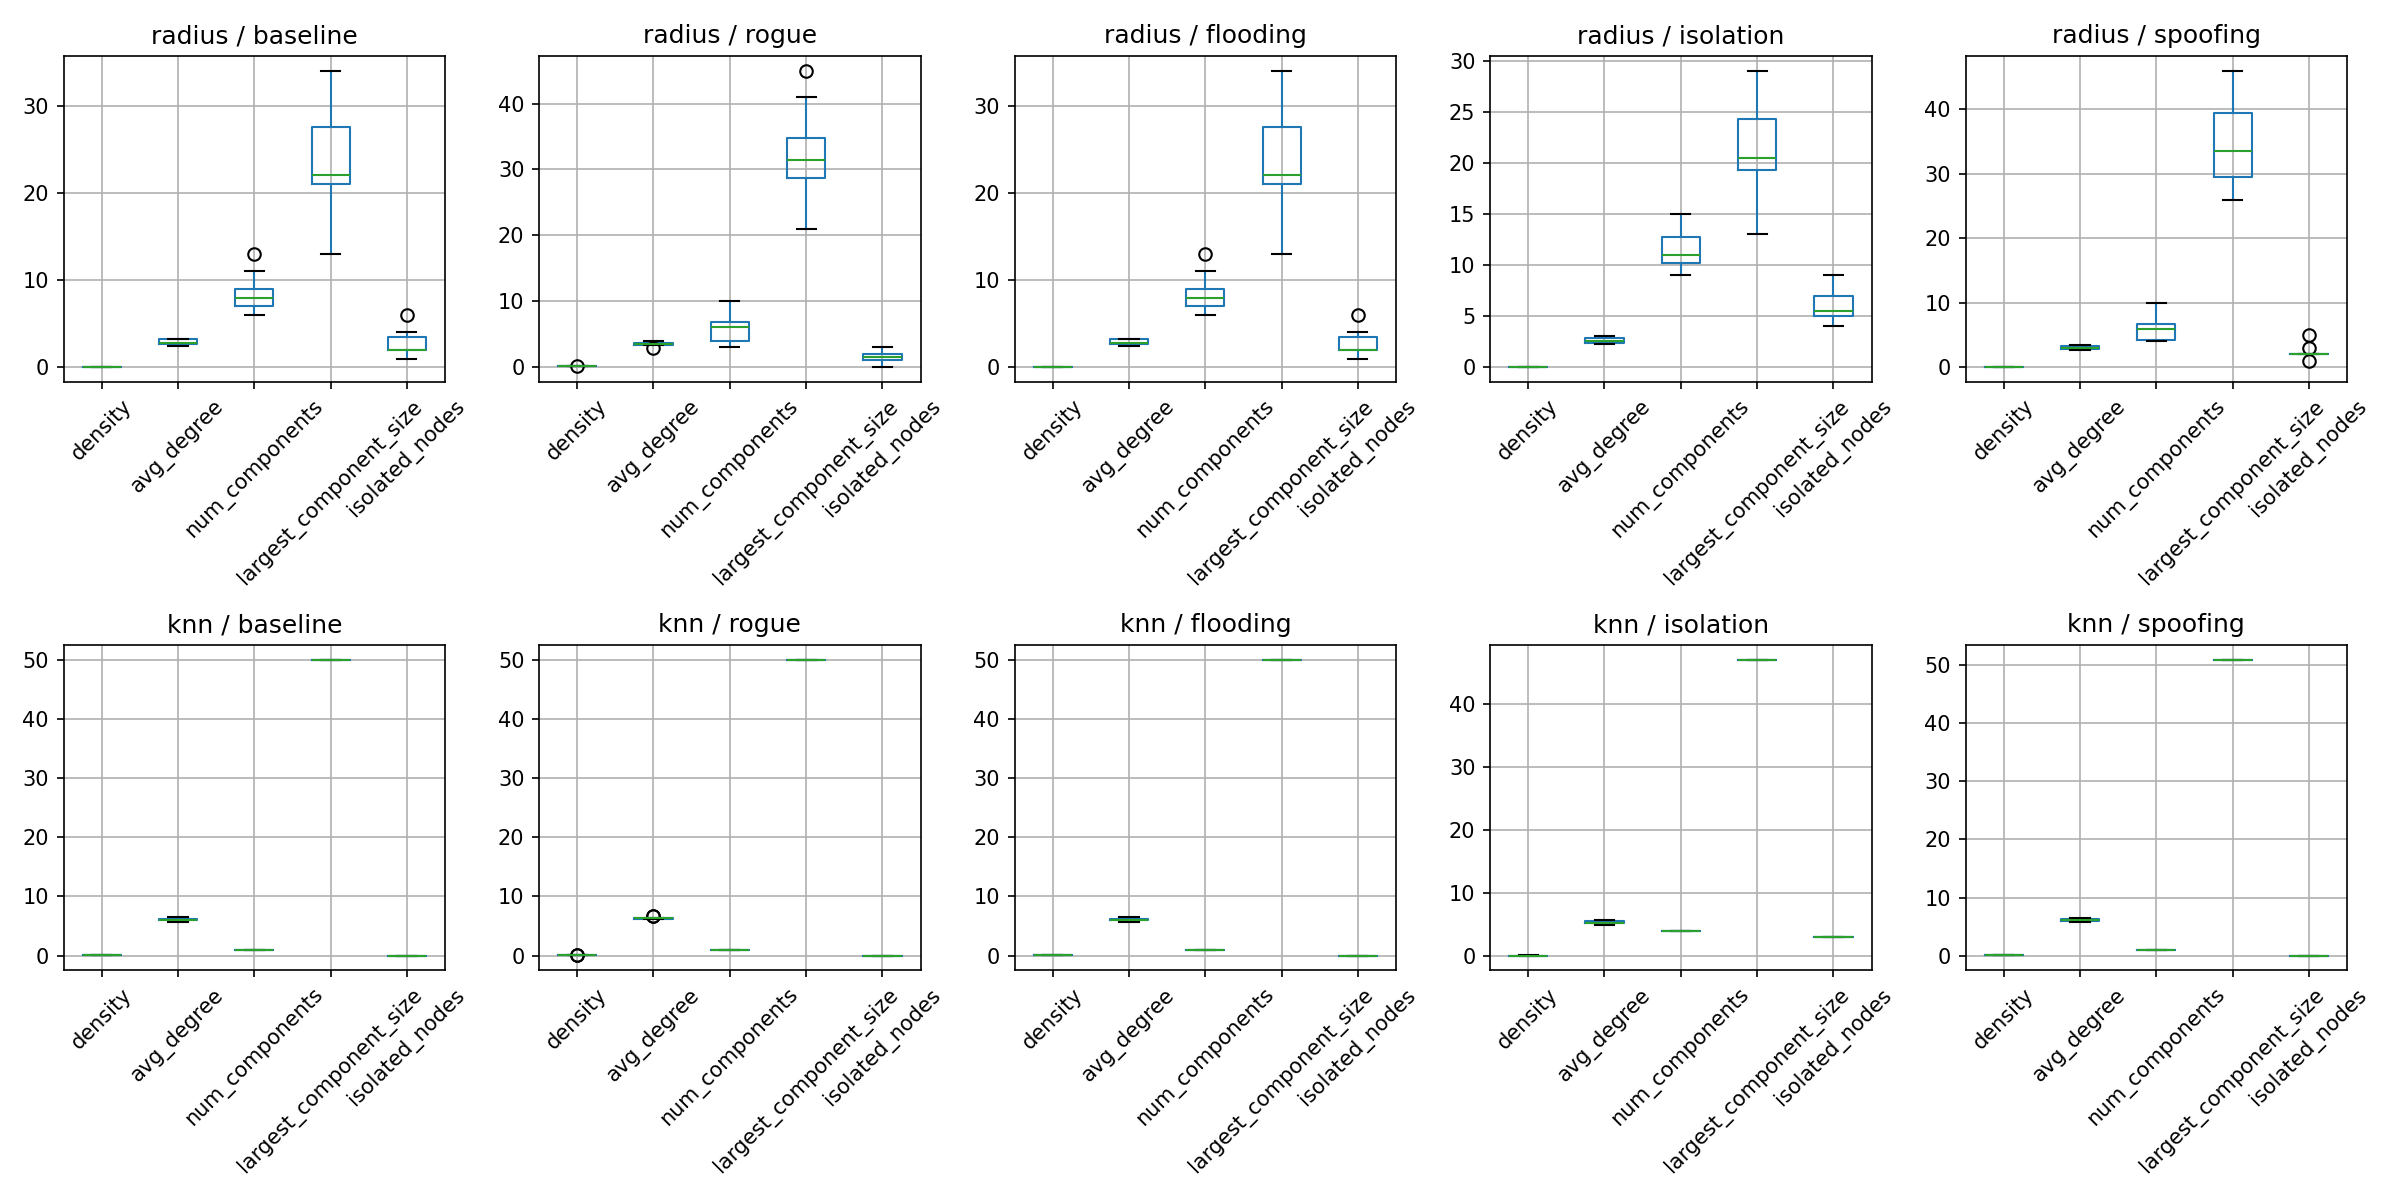

### GEO — stability boxplots

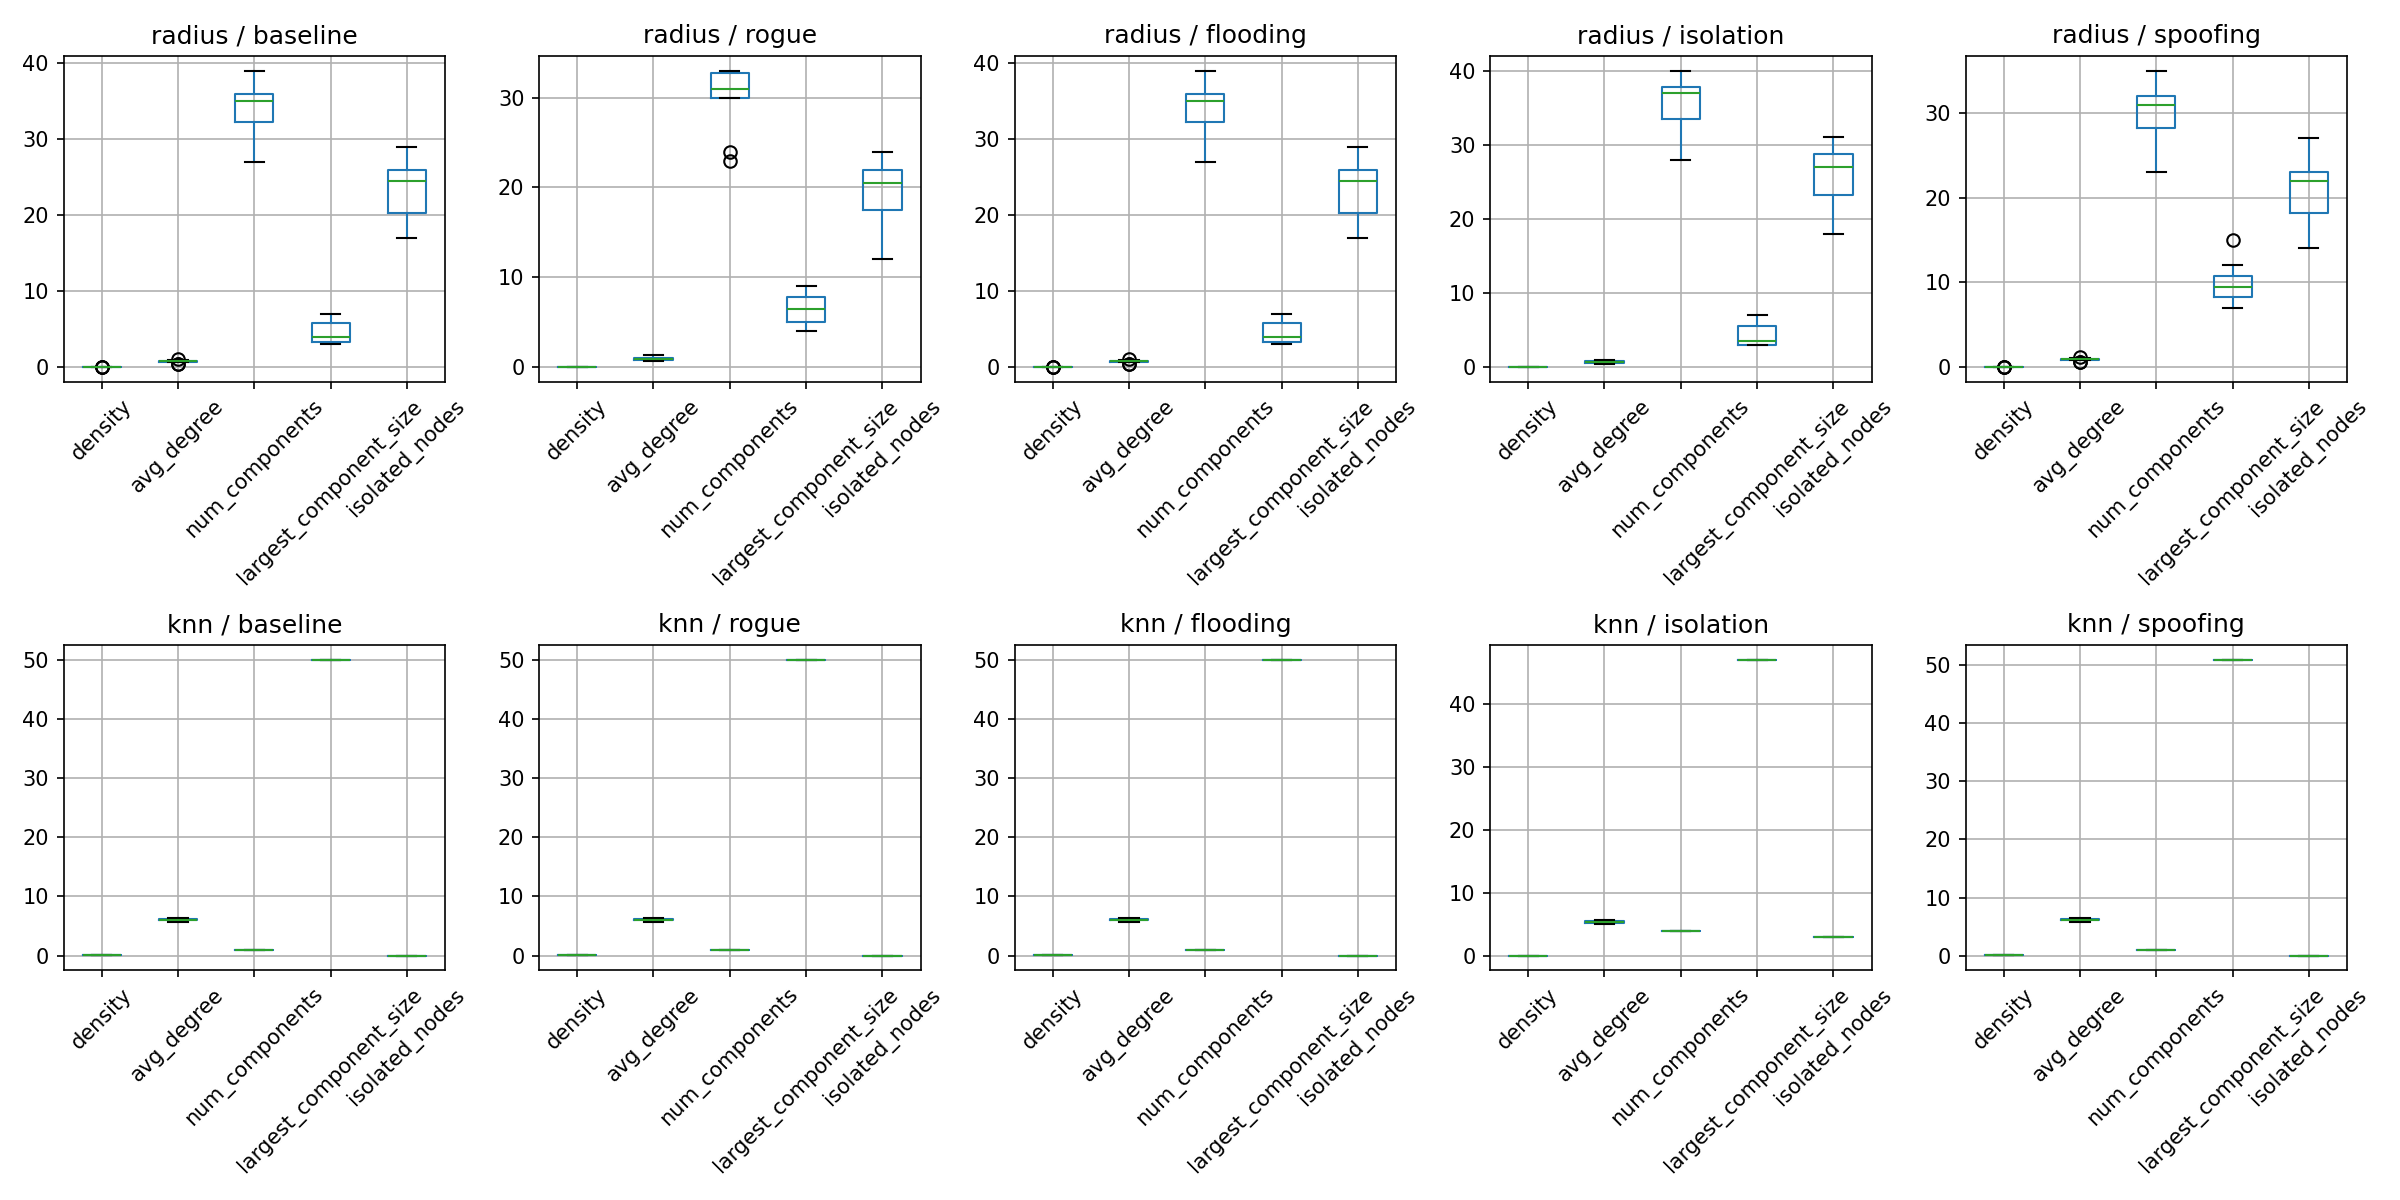

In [7]:
for coord in RUN_COORDS:
    img_path = coord_root(coord) / "figures" / "stability_boxplots.png"
    display(Markdown(f"### {coord.upper()} — stability boxplots"))
    if img_path.exists():
        display(Image(filename=str(img_path), width=900))
    else:
        display(Markdown(f"**Файл не найден:** `{img_path}`"))

## 6. Итоговая интерпретация

1. `plane`-режим остаётся базовой абстрактной моделью для чистого топологического анализа.
2. `geo`-режим усиливает интерпретируемость, потому что координаты и расстояния имеют физический смысл: долгота/широта и метры.
3. `radius graph` обычно чувствительнее к разрывам и локальным топологическим изменениям.
4. `k-NN graph` задаёт более контролируемую связность и полезен как альтернативная модель сравнения.
5. `flooding` корректнее фиксируется нагрузочными метриками, а не структурой графа.
6. `spoofing` полезно анализировать не только по глобальным метрикам, но и через локальные изменения центральности и ложные связи.